In [ ]:
# ============================================================
# 2.0 CONFIGURACI?N GENERAL DEL EDA
# Ruta C: Regresión temporal
# ============================================================

import sys
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import TimeSeriesSplit

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

DATA_FILE = Path("data/processed/crypto_binance_master_1h.csv")

print("=" * 72)
print("ANÁLISIS EXPLORATORIO DE DATOS")
print("RUTA C: REGRESIÓN TEMPORAL")
print("=" * 72)

print(f"\nPython: {sys.version.split()[0]}")
print(f"Semilla aleatoria: {SEED}")
print(f"Archivo de datos: {DATA_FILE}")

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"No se encontró el archivo: {DATA_FILE}"
    )

print("\nArchivo encontrado correctamente.")


In [ ]:
# ============================================================
# CARGA DEL DATASET MAESTRO
# ============================================================

df = pd.read_csv(
    DATA_FILE,
    parse_dates=["open_time", "close_time"]
)

df = (
    df
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

print("=" * 72)
print("DATASET MAESTRO")
print("=" * 72)

print(f"\nFilas:     {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")

print("\nObservaciones por criptoactivo:")
display(
    df["symbol"]
    .value_counts()
    .sort_index()
    .rename("observaciones")
    .to_frame()
)

print("\nCobertura temporal general:")
print("Inicio:", df["open_time"].min())
print("Final: ", df["open_time"].max())

display(df.head())


In [ ]:
# ============================================================
# PERIODO TEMPORAL COMÚN
# ============================================================

inicio_comun = (
    df.groupby("symbol")["open_time"]
    .min()
    .max()
)

fin_comun = (
    df.groupby("symbol")["open_time"]
    .max()
    .min()
)

df_common = df[
    (df["open_time"] >= inicio_comun) &
    (df["open_time"] <= fin_comun)
].copy()

df_common = (
    df_common
    .sort_values(["symbol", "open_time"])
    .reset_index(drop=True)
)

print("=" * 72)
print("PERIODO TEMPORAL COMÚN")
print("=" * 72)

print("\nInicio común:", inicio_comun)
print("Final común: ", fin_comun)

print(f"\nObservaciones totales: {len(df_common):,}")

print("\nObservaciones por criptoactivo:")
display(
    df_common["symbol"]
    .value_counts()
    .sort_index()
    .rename("observaciones")
    .to_frame()
)


In [ ]:
# ============================================================
# SEGMENTOS TEMPORALES CONTINUOS
# ============================================================

df_common["time_diff"] = (
    df_common
    .groupby("symbol")["open_time"]
    .diff()
)

df_common["gap_before"] = (
    df_common["time_diff"] > pd.Timedelta(hours=1)
)

df_common["segment_id"] = (
    df_common
    .groupby("symbol")["gap_before"]
    .cumsum()
)

gap_summary = (
    df_common[df_common["gap_before"]]
    .groupby("symbol")
    .size()
    .rename("huecos_detectados")
    .to_frame()
)

print("=" * 72)
print("CONTINUIDAD TEMPORAL")
print("=" * 72)

display(gap_summary)

print("\nNúmero de segmentos continuos por activo:")

display(
    df_common
    .groupby("symbol")["segment_id"]
    .nunique()
    .rename("segmentos")
    .to_frame()
)


In [ ]:
# ============================================================
# CONSTRUCCIÓN DE LA VARIABLE OBJETIVO
# ============================================================

df_model = df_common.copy()

df_model["log_return_1h"] = (
    df_model
    .groupby(["symbol", "segment_id"])["close"]
    .transform(
        lambda x: 100 * np.log(x / x.shift(1))
    )
)

df_model["target_return_t1"] = (
    df_model
    .groupby(["symbol", "segment_id"])["log_return_1h"]
    .shift(-1)
)

df_model["target_time"] = (
    df_model
    .groupby(["symbol", "segment_id"])["open_time"]
    .shift(-1)
)

df_model_valid = df_model.dropna(
    subset=[
        "log_return_1h",
        "target_return_t1",
        "target_time"
    ]
).copy()

print("=" * 72)
print("VARIABLE OBJETIVO")
print("=" * 72)

print(f"\nObservaciones antes: {len(df_model):,}")
print(f"Observaciones válidas: {len(df_model_valid):,}")
print(
    "Observaciones excluidas por límites de segmentos:",
    f"{len(df_model) - len(df_model_valid):,}"
)

display(
    df_model_valid[
        [
            "symbol",
            "open_time",
            "close",
            "log_return_1h",
            "target_time",
            "target_return_t1"
        ]
    ].head(10)
)


In [ ]:
# ============================================================
# PARTICIÓN CRONOLÓGICA TRAIN / TEST
# ============================================================

TRAIN_RATIO = 0.80

unique_times = (
    df_model_valid["open_time"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

split_index = int(len(unique_times) * TRAIN_RATIO)

test_start = pd.Timestamp(
    unique_times.iloc[split_index]
)

# ------------------------------------------------------------
# TRAIN:
# tanto la información en t como el target t+1 deben estar
# completamente antes del inicio del test.
# ------------------------------------------------------------

train = df_model_valid[
    (df_model_valid["open_time"] < test_start) &
    (df_model_valid["target_time"] < test_start)
].copy()

# ------------------------------------------------------------
# TEST:
# observaciones cuyo instante t pertenece al periodo reservado.
# ------------------------------------------------------------

test = df_model_valid[
    df_model_valid["open_time"] >= test_start
].copy()

print("=" * 72)
print("PARTICIÓN CRONOLÓGICA")
print("=" * 72)

print("\nInicio del conjunto de prueba:")
print(test_start)

print("\nTRAIN")
print(f"Observaciones: {len(train):,}")
print("Inicio:", train["open_time"].min())
print("Final t:", train["open_time"].max())
print("último target:", train["target_time"].max())

print("\nTEST")
print(f"Observaciones: {len(test):,}")
print("Inicio:", test["open_time"].min())
print("Final:", test["open_time"].max())

print("\nPorcentaje aproximado:")
print(f"Train: {100 * len(train) / (len(train) + len(test)):.2f}%")
print(f"Test:  {100 * len(test) / (len(train) + len(test)):.2f}%")


In [ ]:
# ============================================================
# VERIFICACIÓN DE LA PARTICIÓN TEMPORAL
# ============================================================

assert train["open_time"].max() < test["open_time"].min()
assert train["target_time"].max() < test["open_time"].min()

train_times = set(train["open_time"])
test_times = set(test["open_time"])

overlap = train_times.intersection(test_times)

print("=" * 72)
print("VERIFICACIÓN TRAIN / TEST")
print("=" * 72)

print("\nTimestamps compartidos entre train y test:")
print(len(overlap))

print("\nObservaciones de entrenamiento por activo:")
display(
    train["symbol"]
    .value_counts()
    .sort_index()
    .rename("train")
    .to_frame()
)

print("\nObservaciones de prueba por activo:")
display(
    test["symbol"]
    .value_counts()
    .sort_index()
    .rename("test")
    .to_frame()
)

print("\nVerificación temporal: CORRECTA")
print("No existe solapamiento temporal entre train y test.")


In [ ]:
# ============================================================
# 2.1.1 ESTADISTICOS DESCRIPTIVOS DEL TARGET
# SOLO TRAIN
# ============================================================

target_col = "target_return_t1"

target_stats = (
    train
    .groupby("symbol")[target_col]
    .agg(
        observaciones="count",
        media="mean",
        mediana="median",
        desviacion="std",
        minimo="min",
        maximo="max",
        asimetria="skew"
    )
)

target_stats["curtosis"] = (
    train
    .groupby("symbol")[target_col]
    .apply(pd.Series.kurt)
)

quantiles = (
    train
    .groupby("symbol")[target_col]
    .quantile([
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ])
    .unstack()
)

quantiles.columns = [
    "P01",
    "P05",
    "P25",
    "P50",
    "P75",
    "P95",
    "P99"
]

target_stats = target_stats.join(quantiles)

print("=" * 90)
print("ESTADISTICOS DESCRIPTIVOS DE LA VARIABLE OBJETIVO - TRAIN")
print("=" * 90)

display(target_stats.round(6))


In [ ]:
# ============================================================
# JARQUE-BERA POR CRIPTOACTIVO
# ============================================================

jb_rows = []

for symbol, g in train.groupby("symbol"):

    x = g[target_col].dropna()

    jb = stats.jarque_bera(x)

    jb_rows.append({
        "symbol": symbol,
        "n": len(x),
        "JB": jb.statistic,
        "p_value": jb.pvalue,
        "asimetria": stats.skew(x, bias=False),
        "curtosis_exceso": stats.kurtosis(
            x,
            fisher=True,
            bias=False
        )
    })

jb_df = pd.DataFrame(jb_rows).set_index("symbol")

display(jb_df.round(6))

print(
    "\nNota: con muestras grandes, el valor p debe interpretarse "
    "junto con la asimetria, curtosis y evidencia grafica."
)


In [ ]:
# ============================================================
# HISTOGRAMAS DEL TARGET
# ============================================================

symbols = sorted(train["symbol"].unique())

for symbol in symbols:

    temp = train.loc[
        train["symbol"] == symbol,
        target_col
    ].dropna()

    q_low = temp.quantile(0.005)
    q_high = temp.quantile(0.995)

    temp_plot = temp[
        (temp >= q_low) &
        (temp <= q_high)
    ]

    plt.figure(figsize=(10, 5))

    plt.hist(
        temp_plot,
        bins=100,
        density=True,
        alpha=0.8
    )

    plt.axvline(
        temp.mean(),
        linestyle="--",
        label=f"Media = {temp.mean():.4f}%"
    )

    plt.axvline(
        temp.median(),
        linestyle=":",
        label=f"Mediana = {temp.median():.4f}%"
    )

    plt.title(
        f"Distribucion de target_return_t1 - {symbol} (TRAIN)"
    )

    plt.xlabel("Rendimiento logaritmico futuro a 1 hora (%)")
    plt.ylabel("Densidad")

    plt.legend()
    plt.grid(alpha=0.20)

    plt.show()


In [ ]:
# ============================================================
# OUTLIERS SEGUN IQR
# ============================================================

outlier_rows = []

for symbol, g in train.groupby("symbol"):

    x = g[target_col].dropna()

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)

    iqr = q3 - q1

    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    mask = (
        (x < limite_inf) |
        (x > limite_sup)
    )

    n_outliers = int(mask.sum())

    outlier_rows.append({
        "symbol": symbol,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": limite_inf,
        "limite_superior": limite_sup,
        "outliers_IQR": n_outliers,
        "porcentaje_outliers": (
            100 * n_outliers / len(x)
        )
    })

outlier_df = (
    pd.DataFrame(outlier_rows)
    .set_index("symbol")
)

display(outlier_df.round(6))


In [ ]:
# ============================================================
# BOXPLOT DEL TARGET POR CRIPTOACTIVO
# ============================================================

plt.figure(figsize=(11, 6))

train.boxplot(
    column=target_col,
    by="symbol",
    grid=False
)

plt.title(
    "Distribucion del rendimiento futuro por criptoactivo - TRAIN"
)

plt.suptitle("")

plt.xlabel("Criptoactivo")
plt.ylabel("Rendimiento logaritmico t+1 (%)")

plt.show()


In [ ]:
# ============================================================
# EVALUACION DE POSITIVIDAD DEL TARGET
# ============================================================

target_range = pd.DataFrame({
    "minimo": (
        train.groupby("symbol")[target_col]
        .min()
    ),
    "maximo": (
        train.groupby("symbol")[target_col]
        .max()
    ),
    "n_negativos": (
        train.groupby("symbol")[target_col]
        .apply(lambda x: int((x < 0).sum()))
    ),
    "n_ceros": (
        train.groupby("symbol")[target_col]
        .apply(lambda x: int((x == 0).sum()))
    ),
    "n_positivos": (
        train.groupby("symbol")[target_col]
        .apply(lambda x: int((x > 0).sum()))
    )
})

display(target_range)

print("\nConclusion preliminar:")
print(
    "El target contiene valores negativos, cero y positivos; "
    "por tanto, log y Box-Cox no son directamente aplicables "
    "sin alterar la escala original."
)


In [ ]:
# ============================================================
# COMPORTAMIENTO TEMPORAL DEL TARGET
# AGREGACION DIARIA
# ============================================================

target_daily = (
    train
    .set_index("open_time")
    .groupby("symbol")[target_col]
    .resample("1D")
    .mean()
    .rename("target_daily_mean")
    .reset_index()
)

for symbol in symbols:

    temp = target_daily[
        target_daily["symbol"] == symbol
    ]

    plt.figure(figsize=(12, 4))

    plt.plot(
        temp["open_time"],
        temp["target_daily_mean"]
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"Media diaria de target_return_t1 - {symbol} (TRAIN)"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Rendimiento futuro medio diario (%)")

    plt.grid(alpha=0.20)

    plt.show()


In [ ]:
# ============================================================
# 2.2.1 DEFINICION DE VARIABLES PARA EL ANALISIS
# ============================================================

categorical_vars = [
    "symbol"
]

numeric_vars = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_volume",
    "taker_buy_quote_volume"
]

excluded_vars = [
    "open_time",
    "close_time",
    "target_time",
    "time_diff",
    "gap_before",
    "segment_id",
    "log_return_1h",
    "target_return_t1"
]

print("=" * 80)
print("VARIABLES DEL ANALISIS UNIDIMENSIONAL")
print("=" * 80)

print("\nCategoricas:")
print(categorical_vars)

print("\nNumericas:")
for v in numeric_vars:
    print("-", v)

print("\nVariables reservadas para otras secciones:")
for v in excluded_vars:
    print("-", v)


In [ ]:
# ============================================================
# TIPO, CARDINALIDAD Y FALTANTES
# ============================================================

analysis_vars = categorical_vars + numeric_vars

variable_info = []

for col in analysis_vars:

    variable_info.append({
        "variable": col,
        "tipo": str(train[col].dtype),
        "valores_unicos": train[col].nunique(dropna=True),
        "faltantes": int(train[col].isna().sum()),
        "porcentaje_faltantes": (
            100 * train[col].isna().mean()
        )
    })

variable_info_df = pd.DataFrame(variable_info)

display(variable_info_df)


In [ ]:
# ============================================================
# FRECUENCIAS DE SYMBOL
# ============================================================

symbol_freq = (
    train["symbol"]
    .value_counts()
    .sort_index()
    .rename("frecuencia")
    .to_frame()
)

symbol_freq["porcentaje"] = (
    100 * symbol_freq["frecuencia"] / len(train)
)

display(symbol_freq.round(4))

rare_threshold = 1.0

rare_categories = symbol_freq[
    symbol_freq["porcentaje"] < rare_threshold
]

print()
print("Categorias con menos del 1% de las observaciones:")
print(len(rare_categories))

if len(rare_categories) == 0:
    print("No se detectaron categorias raras.")
else:
    display(rare_categories)


In [ ]:
# ============================================================
# GRAFICO DE FRECUENCIAS DE SYMBOL
# ============================================================

plt.figure(figsize=(9, 5))

symbol_freq["frecuencia"].plot(
    kind="bar"
)

plt.title(
    "Numero de observaciones por criptoactivo - TRAIN"
)

plt.xlabel("Criptoactivo")
plt.ylabel("Frecuencia")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)

plt.show()


In [ ]:
# ============================================================
# ESTADISTICOS DESCRIPTIVOS POR VARIABLE Y CRIPTOACTIVO
# ============================================================

stats_rows = []

for symbol, g in train.groupby("symbol"):

    for col in numeric_vars:

        x = g[col].dropna()

        stats_rows.append({
            "symbol": symbol,
            "variable": col,
            "n": len(x),
            "media": x.mean(),
            "mediana": x.median(),
            "desviacion": x.std(),
            "minimo": x.min(),
            "P01": x.quantile(0.01),
            "P05": x.quantile(0.05),
            "P25": x.quantile(0.25),
            "P75": x.quantile(0.75),
            "P95": x.quantile(0.95),
            "P99": x.quantile(0.99),
            "maximo": x.max(),
            "asimetria": x.skew(),
            "curtosis": x.kurt()
        })

univariate_stats = pd.DataFrame(stats_rows)

display(
    univariate_stats
    .sort_values(["variable", "symbol"])
    .round(6)
)


In [ ]:
# ============================================================
# TABLA DE ASIMETRIA Y CURTOSIS
# ============================================================

shape_stats = (
    univariate_stats[
        [
            "symbol",
            "variable",
            "asimetria",
            "curtosis"
        ]
    ]
    .sort_values(
        ["variable", "symbol"]
    )
)

display(shape_stats.round(6))


In [ ]:
# ============================================================
# JARQUE-BERA POR VARIABLE Y ACTIVO
# ============================================================

normality_rows = []

for symbol, g in train.groupby("symbol"):

    for col in numeric_vars:

        x = g[col].dropna()

        jb = stats.jarque_bera(x)

        normality_rows.append({
            "symbol": symbol,
            "variable": col,
            "n": len(x),
            "JB": jb.statistic,
            "p_value": jb.pvalue
        })

normality_df = pd.DataFrame(normality_rows)

display(
    normality_df
    .sort_values(["variable", "symbol"])
    .round(6)
)


In [ ]:
# ============================================================
# HISTOGRAMAS POR VARIABLE Y CRIPTOACTIVO
# ============================================================

symbols = sorted(train["symbol"].unique())

for col in numeric_vars:

    print("=" * 90)
    print("VARIABLE:", col)
    print("=" * 90)

    for symbol in symbols:

        x = train.loc[
            train["symbol"] == symbol,
            col
        ].dropna()

        q_low = x.quantile(0.005)
        q_high = x.quantile(0.995)

        x_plot = x[
            (x >= q_low) &
            (x <= q_high)
        ]

        plt.figure(figsize=(9, 4))

        plt.hist(
            x_plot,
            bins=80,
            density=True
        )

        plt.axvline(
            x.mean(),
            linestyle="--",
            label=f"Media = {x.mean():.4f}"
        )

        plt.axvline(
            x.median(),
            linestyle=":",
            label=f"Mediana = {x.median():.4f}"
        )

        plt.title(
            f"{col} - {symbol} (TRAIN)"
        )

        plt.xlabel(col)
        plt.ylabel("Densidad")

        plt.legend()
        plt.grid(alpha=0.2)

        plt.show()


In [ ]:
# ============================================================
# OUTLIERS IQR
# ============================================================

iqr_rows = []

for symbol, g in train.groupby("symbol"):

    for col in numeric_vars:

        x = g[col].dropna()

        q1 = x.quantile(0.25)
        q3 = x.quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask = (
            (x < lower) |
            (x > upper)
        )

        n_out = int(mask.sum())

        iqr_rows.append({
            "symbol": symbol,
            "variable": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "limite_inferior": lower,
            "limite_superior": upper,
            "outliers": n_out,
            "porcentaje_outliers": (
                100 * n_out / len(x)
            )
        })

iqr_df = pd.DataFrame(iqr_rows)

display(
    iqr_df
    .sort_values(["variable", "symbol"])
    .round(6)
)


In [ ]:
# ============================================================
# BOXPLOTS POR VARIABLE Y CRIPTOACTIVO
# ============================================================

for col in numeric_vars:

    plt.figure(figsize=(11, 5))

    train.boxplot(
        column=col,
        by="symbol",
        grid=False
    )

    plt.title(
        f"Boxplot de {col} por criptoactivo - TRAIN"
    )

    plt.suptitle("")

    plt.xlabel("Criptoactivo")
    plt.ylabel(col)

    plt.show()


In [ ]:
# ============================================================
# CONFIGURACION 2.3
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression
from IPython.display import display

target_col = "target_return_t1"

candidate_predictors = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_volume",
    "taker_buy_quote_volume",
    "log_return_1h"
]

bivariate_numeric_vars = [
    c for c in candidate_predictors
    if c in train.columns
]

print("=" * 75)
print("VARIABLES UTILIZADAS EN 2.3")
print("=" * 75)

for col in bivariate_numeric_vars:
    print("-", col)

print()
print("Target:", target_col)
print("Numero de predictores:", len(bivariate_numeric_vars))


In [ ]:
# ============================================================
# PEARSON Y SPEARMAN
# ============================================================

corr_rows = []

for symbol, g in train.groupby("symbol"):

    for predictor in bivariate_numeric_vars:

        temp = (
            g[[predictor, target_col]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        if len(temp) < 3:
            continue

        x = temp[predictor]
        y = temp[target_col]

        pearson_r, pearson_p = stats.pearsonr(x, y)
        spearman_rho, spearman_p = stats.spearmanr(x, y)

        corr_rows.append({
            "symbol": symbol,
            "predictor": predictor,
            "n": len(temp),
            "pearson_r": pearson_r,
            "pearson_p": pearson_p,
            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p
        })

corr_target_df = pd.DataFrame(corr_rows)

display(
    corr_target_df
    .sort_values(
        "spearman_rho",
        key=lambda s: s.abs(),
        ascending=False
    )
    .round(6)
)


In [ ]:
# ============================================================
# BENJAMINI-HOCHBERG
# ============================================================

def benjamini_hochberg(p_values):

    p_values = np.asarray(p_values, dtype=float)

    m = len(p_values)

    order = np.argsort(p_values)
    ranked = p_values[order]

    adjusted = ranked * m / np.arange(1, m + 1)

    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(adjusted, 0, 1)

    result = np.empty(m)
    result[order] = adjusted

    return result


corr_target_df["pearson_p_FDR"] = (
    benjamini_hochberg(
        corr_target_df["pearson_p"].values
    )
)

corr_target_df["spearman_p_FDR"] = (
    benjamini_hochberg(
        corr_target_df["spearman_p"].values
    )
)

display(
    corr_target_df[
        [
            "symbol",
            "predictor",
            "pearson_r",
            "pearson_p_FDR",
            "spearman_rho",
            "spearman_p_FDR"
        ]
    ].round(6)
)


In [ ]:
# ============================================================
# INFORMACION MUTUA
# ============================================================

mi_rows = []

for symbol, g in train.groupby("symbol"):

    temp = (
        g[bivariate_numeric_vars + [target_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    X = temp[bivariate_numeric_vars]
    y = temp[target_col]

    mi_values = mutual_info_regression(
        X,
        y,
        random_state=42
    )

    for predictor, value in zip(
        bivariate_numeric_vars,
        mi_values
    ):

        mi_rows.append({
            "symbol": symbol,
            "predictor": predictor,
            "mutual_information": value
        })

mi_df = pd.DataFrame(mi_rows)

display(
    mi_df
    .sort_values(
        ["symbol", "mutual_information"],
        ascending=[True, False]
    )
    .round(6)
)


In [ ]:
# ============================================================
# RESUMEN DE ASOCIACION
# ============================================================

association_summary = (
    corr_target_df
    .merge(
        mi_df,
        on=["symbol", "predictor"],
        how="left"
    )
)

association_summary["abs_spearman"] = (
    association_summary["spearman_rho"].abs()
)

display(
    association_summary
    .sort_values(
        ["symbol", "abs_spearman"],
        ascending=[True, False]
    )
    .round(6)
)


In [ ]:
# ============================================================
# TOP 3 + HEXBIN
# ============================================================

top_predictors = (
    association_summary
    .sort_values(
        ["symbol", "abs_spearman"],
        ascending=[True, False]
    )
    .groupby("symbol")
    .head(3)
)

display(
    top_predictors[
        [
            "symbol",
            "predictor",
            "pearson_r",
            "spearman_rho",
            "mutual_information"
        ]
    ].round(6)
)

for _, row in top_predictors.iterrows():

    symbol = row["symbol"]
    predictor = row["predictor"]

    temp = (
        train.loc[
            train["symbol"] == symbol,
            [predictor, target_col]
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    x_low = temp[predictor].quantile(0.005)
    x_high = temp[predictor].quantile(0.995)

    y_low = temp[target_col].quantile(0.005)
    y_high = temp[target_col].quantile(0.995)

    temp_plot = temp[
        temp[predictor].between(x_low, x_high)
        &
        temp[target_col].between(y_low, y_high)
    ]

    plt.figure(figsize=(9, 5))

    hb = plt.hexbin(
        temp_plot[predictor],
        temp_plot[target_col],
        gridsize=50,
        mincnt=1
    )

    plt.colorbar(
        hb,
        label="Numero de observaciones"
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"{symbol}: {predictor} vs {target_col} - TRAIN"
    )

    plt.xlabel(predictor)
    plt.ylabel(target_col)

    plt.grid(alpha=0.15)

    plt.show()


In [ ]:
# ============================================================
# SYMBOL VS TARGET
# ============================================================

symbol_target_summary = (
    train
    .groupby("symbol")[target_col]
    .agg(
        n="count",
        media="mean",
        mediana="median",
        desviacion="std"
    )
)

display(
    symbol_target_summary.round(6)
)

groups = [
    g[target_col].dropna().values
    for _, g in train.groupby("symbol")
]

kruskal_result = stats.kruskal(*groups)

print()
print("Kruskal-Wallis")
print("H =", round(kruskal_result.statistic, 6))
print("p-value =", kruskal_result.pvalue)


In [ ]:
# ============================================================
# TAMANO DEL EFECTO: ETA CUADRADO
# ============================================================

grand_mean = train[target_col].mean()

ss_total = (
    (train[target_col] - grand_mean) ** 2
).sum()

ss_between = 0.0

for symbol, g in train.groupby("symbol"):

    x = g[target_col].dropna()

    ss_between += (
        len(x) *
        (x.mean() - grand_mean) ** 2
    )

eta_squared = (
    ss_between / ss_total
    if ss_total > 0
    else np.nan
)

print(
    "Eta cuadrado =",
    round(eta_squared, 8)
)


In [ ]:
# ============================================================
# BOXPLOT SYMBOL VS TARGET
# ============================================================

plt.figure(figsize=(10, 5))

train.boxplot(
    column=target_col,
    by="symbol",
    grid=False
)

plt.title(
    "Variable objetivo por criptoactivo - TRAIN"
)

plt.suptitle("")

plt.xlabel("Criptoactivo")
plt.ylabel(
    "Rendimiento logaritmico futuro a 1 hora (%)"
)

plt.show()


In [ ]:
# ============================================================
# MATRICES DE CORRELACION
# ============================================================

heatmap_vars = (
    bivariate_numeric_vars +
    [target_col]
)

for symbol, g in train.groupby("symbol"):

    corr_matrix = (
        g[heatmap_vars]
        .replace([np.inf, -np.inf], np.nan)
        .corr(method="pearson")
    )

    fig, ax = plt.subplots(
        figsize=(11, 9)
    )

    im = ax.imshow(
        corr_matrix.values,
        vmin=-1,
        vmax=1,
        aspect="auto"
    )

    ax.set_xticks(
        np.arange(len(corr_matrix.columns))
    )

    ax.set_yticks(
        np.arange(len(corr_matrix.index))
    )

    ax.set_xticklabels(
        corr_matrix.columns,
        rotation=90
    )

    ax.set_yticklabels(
        corr_matrix.index
    )

    for i in range(len(corr_matrix.index)):
        for j in range(len(corr_matrix.columns)):

            ax.text(
                j,
                i,
                f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=7
            )

    plt.colorbar(
        im,
        ax=ax,
        label="Correlacion de Pearson"
    )

    plt.title(
        f"Matriz de correlacion - {symbol} (TRAIN)"
    )

    plt.tight_layout()
    plt.show()


In [ ]:
# ============================================================
# CORRELACIONES ALTAS ENTRE PREDICTORES
# ============================================================

high_corr_rows = []

for symbol, g in train.groupby("symbol"):

    matrix = (
        g[bivariate_numeric_vars]
        .replace([np.inf, -np.inf], np.nan)
        .corr()
    )

    columns = list(matrix.columns)

    for i in range(len(columns)):

        for j in range(i + 1, len(columns)):

            r = matrix.iloc[i, j]

            if abs(r) >= 0.80:

                high_corr_rows.append({
                    "symbol": symbol,
                    "variable_1": columns[i],
                    "variable_2": columns[j],
                    "correlacion": r
                })

high_corr_df = pd.DataFrame(high_corr_rows)

if len(high_corr_df) == 0:

    print(
        "No se encontraron pares con |r| >= 0.80"
    )

else:

    high_corr_df["abs_correlacion"] = (
        high_corr_df["correlacion"].abs()
    )

    display(
        high_corr_df
        .sort_values(
            "abs_correlacion",
            ascending=False
        )
        .drop(
            columns="abs_correlacion"
        )
        .round(6)
    )


In [ ]:
# ============================================================
# VIF
# ============================================================

vif_rows = []

for symbol, g in train.groupby("symbol"):

    temp = (
        g[bivariate_numeric_vars]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .astype(float)
    )

    stds = temp.std(ddof=0)

    valid_vars = [
        col for col in temp.columns
        if stds[col] > 0
    ]

    X_scaled = (
        temp[valid_vars] -
        temp[valid_vars].mean()
    ) / temp[valid_vars].std(ddof=0)

    for predictor in valid_vars:

        other_vars = [
            c for c in valid_vars
            if c != predictor
        ]

        if len(other_vars) == 0:
            continue

        y_aux = X_scaled[predictor]

        X_aux = X_scaled[other_vars]

        model_aux = LinearRegression()

        model_aux.fit(
            X_aux,
            y_aux
        )

        r2_aux = model_aux.score(
            X_aux,
            y_aux
        )

        if r2_aux >= 1:
            vif = np.inf
        else:
            vif = 1.0 / (1.0 - r2_aux)

        vif_rows.append({
            "symbol": symbol,
            "predictor": predictor,
            "R2_auxiliar": r2_aux,
            "VIF": vif
        })

vif_df = pd.DataFrame(vif_rows)

display(
    vif_df
    .sort_values(
        ["symbol", "VIF"],
        ascending=[True, False]
    )
    .round(4)
)


In [ ]:
# ============================================================
# 2.4.1 CONFIGURACION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from scipy.stats import chi2
from IPython.display import display

multivariate_candidates = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_volume",
    "taker_buy_quote_volume",
    "log_return_1h"
]

multivariate_vars = [
    c for c in multivariate_candidates
    if c in train.columns
]

print("=" * 78)
print("VARIABLES UTILIZADAS EN EL ANALISIS MULTIDIMENSIONAL")
print("=" * 78)

for col in multivariate_vars:
    print("-", col)

print()
print("Numero de variables:", len(multivariate_vars))
print("Numero de criptoactivos:", train["symbol"].nunique())


In [ ]:
# ============================================================
# PREPARACION POR CRIPTOACTIVO
# ============================================================

multivariate_data = {}

for symbol, g in train.groupby("symbol"):

    temp = (
        g[
            ["open_time"] +
            multivariate_vars
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(
        temp[multivariate_vars]
    )

    multivariate_data[symbol] = {
        "data": temp,
        "scaler": scaler,
        "X_scaled": X_scaled
    }

summary_multivariate = pd.DataFrame(
    [
        {
            "symbol": symbol,
            "observaciones": len(info["data"]),
            "variables": len(multivariate_vars)
        }
        for symbol, info in multivariate_data.items()
    ]
).set_index("symbol")

display(summary_multivariate)


In [ ]:
# ============================================================
# PCA POR CRIPTOACTIVO
# ============================================================

pca_results = {}
pca_summary_rows = []

for symbol, info in multivariate_data.items():

    X_scaled = info["X_scaled"]

    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    pca_results[symbol] = {
        "pca": pca,
        "X_pca": X_pca
    }

    cumulative = np.cumsum(
        pca.explained_variance_ratio_
    )

    n80 = int(
        np.argmax(cumulative >= 0.80) + 1
    )

    n90 = int(
        np.argmax(cumulative >= 0.90) + 1
    )

    n95 = int(
        np.argmax(cumulative >= 0.95) + 1
    )

    pca_summary_rows.append({
        "symbol": symbol,
        "PC1_pct": 100 * pca.explained_variance_ratio_[0],
        "PC2_pct": 100 * pca.explained_variance_ratio_[1],
        "PC1_PC2_pct": 100 * cumulative[1],
        "componentes_80pct": n80,
        "componentes_90pct": n90,
        "componentes_95pct": n95
    })

pca_summary_df = (
    pd.DataFrame(pca_summary_rows)
    .set_index("symbol")
)

display(
    pca_summary_df.round(4)
)


In [ ]:
# ============================================================
# VARIANZA EXPLICADA POR PCA
# ============================================================

for symbol, result in pca_results.items():

    pca = result["pca"]

    explained = (
        100 *
        pca.explained_variance_ratio_
    )

    cumulative = np.cumsum(explained)

    components = np.arange(
        1,
        len(explained) + 1
    )

    plt.figure(figsize=(9, 5))

    plt.bar(
        components,
        explained,
        alpha=0.7,
        label="Varianza individual"
    )

    plt.plot(
        components,
        cumulative,
        marker="o",
        label="Varianza acumulada"
    )

    plt.axhline(
        80,
        linestyle="--",
        linewidth=1,
        label="80%"
    )

    plt.axhline(
        90,
        linestyle=":",
        linewidth=1,
        label="90%"
    )

    plt.xlabel("Componente principal")
    plt.ylabel("Varianza explicada (%)")

    plt.title(
        f"Varianza explicada por PCA - {symbol} (TRAIN)"
    )

    plt.xticks(components)
    plt.legend()
    plt.grid(alpha=0.2)

    plt.show()


In [ ]:
# ============================================================
# CARGAS DE PC1 Y PC2
# ============================================================

loading_rows = []

for symbol, result in pca_results.items():

    pca = result["pca"]

    for j, variable in enumerate(multivariate_vars):

        loading_rows.append({
            "symbol": symbol,
            "variable": variable,
            "PC1": pca.components_[0, j],
            "PC2": pca.components_[1, j]
        })

pca_loadings_df = pd.DataFrame(
    loading_rows
)

display(
    pca_loadings_df
    .sort_values(
        ["symbol", "PC1"],
        key=lambda s: s.abs()
        if s.name == "PC1"
        else s,
        ascending=[True, False]
    )
    .round(5)
)


In [ ]:
# ============================================================
# CARGAS PC1 VS PC2
# ============================================================

for symbol in sorted(
    pca_loadings_df["symbol"].unique()
):

    temp = pca_loadings_df[
        pca_loadings_df["symbol"] == symbol
    ]

    plt.figure(figsize=(8, 6))

    plt.scatter(
        temp["PC1"],
        temp["PC2"]
    )

    for _, row in temp.iterrows():

        plt.text(
            row["PC1"],
            row["PC2"],
            row["variable"],
            fontsize=8
        )

    plt.axhline(
        0,
        linewidth=1,
        linestyle="--"
    )

    plt.axvline(
        0,
        linewidth=1,
        linestyle="--"
    )

    plt.xlabel("Carga en PC1")
    plt.ylabel("Carga en PC2")

    plt.title(
        f"Cargas PCA - {symbol} (TRAIN)"
    )

    plt.grid(alpha=0.2)

    plt.show()


In [ ]:
# ============================================================
# PROYECCION PC1 VS PC2
# ============================================================

rng = np.random.default_rng(42)

for symbol, result in pca_results.items():

    X_pca = result["X_pca"]

    n = len(X_pca)

    if n > 5000:
        idx = rng.choice(
            n,
            size=5000,
            replace=False
        )
    else:
        idx = np.arange(n)

    plt.figure(figsize=(8, 6))

    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        s=10,
        alpha=0.35
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.axvline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")

    plt.title(
        f"Proyeccion PCA PC1-PC2 - {symbol} (TRAIN)"
    )

    plt.grid(alpha=0.2)

    plt.show()


In [ ]:
# ============================================================
# ISOLATION FOREST
# ============================================================

isolation_rows = []
isolation_results = {}

for symbol, info in multivariate_data.items():

    X_scaled = info["X_scaled"]

    model_iso = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=42,
        n_jobs=-1
    )

    labels = model_iso.fit_predict(
        X_scaled
    )

    scores = model_iso.decision_function(
        X_scaled
    )

    is_outlier = labels == -1

    isolation_results[symbol] = {
        "labels": labels,
        "scores": scores,
        "is_outlier": is_outlier
    }

    n_outliers = int(
        is_outlier.sum()
    )

    isolation_rows.append({
        "symbol": symbol,
        "observaciones": len(labels),
        "outliers_isolation_forest": n_outliers,
        "porcentaje_outliers": (
            100 * n_outliers / len(labels)
        )
    })

isolation_summary_df = (
    pd.DataFrame(isolation_rows)
    .set_index("symbol")
)

display(
    isolation_summary_df.round(4)
)


In [ ]:
# ============================================================
# ISOLATION FOREST EN EL ESPACIO PCA
# ============================================================

for symbol in sorted(
    multivariate_data.keys()
):

    X_pca = pca_results[symbol]["X_pca"]

    is_outlier = isolation_results[
        symbol
    ]["is_outlier"]

    normal_idx = np.where(
        ~is_outlier
    )[0]

    out_idx = np.where(
        is_outlier
    )[0]

    rng = np.random.default_rng(42)

    if len(normal_idx) > 5000:
        normal_plot = rng.choice(
            normal_idx,
            size=5000,
            replace=False
        )
    else:
        normal_plot = normal_idx

    if len(out_idx) > 1500:
        out_plot = rng.choice(
            out_idx,
            size=1500,
            replace=False
        )
    else:
        out_plot = out_idx

    plt.figure(figsize=(9, 6))

    plt.scatter(
        X_pca[normal_plot, 0],
        X_pca[normal_plot, 1],
        s=9,
        alpha=0.25,
        label="Observacion regular"
    )

    plt.scatter(
        X_pca[out_plot, 0],
        X_pca[out_plot, 1],
        s=14,
        alpha=0.65,
        label="Candidato atipico"
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")

    plt.title(
        f"Isolation Forest sobre espacio PCA - {symbol}"
    )

    plt.legend()
    plt.grid(alpha=0.2)

    plt.show()


In [ ]:
# ============================================================
# DISTANCIA DE MAHALANOBIS
# ============================================================

mahalanobis_rows = []
mahalanobis_results = {}

for symbol, info in multivariate_data.items():

    X = info["X_scaled"]

    mean_vector = X.mean(axis=0)

    covariance = np.cov(
        X,
        rowvar=False
    )

    covariance_inv = np.linalg.pinv(
        covariance
    )

    centered = (
        X - mean_vector
    )

    md2 = np.einsum(
        "ij,jk,ik->i",
        centered,
        covariance_inv,
        centered
    )

    df_chi = X.shape[1]

    threshold = chi2.ppf(
        0.999,
        df=df_chi
    )

    is_outlier = (
        md2 > threshold
    )

    mahalanobis_results[symbol] = {
        "md2": md2,
        "threshold": threshold,
        "is_outlier": is_outlier
    }

    n_outliers = int(
        is_outlier.sum()
    )

    mahalanobis_rows.append({
        "symbol": symbol,
        "observaciones": len(md2),
        "umbral_chi2_99_9": threshold,
        "outliers_mahalanobis": n_outliers,
        "porcentaje_outliers": (
            100 * n_outliers / len(md2)
        )
    })

mahalanobis_summary_df = (
    pd.DataFrame(mahalanobis_rows)
    .set_index("symbol")
)

display(
    mahalanobis_summary_df.round(4)
)


In [ ]:
# ============================================================
# COINCIDENCIA ENTRE ISOLATION FOREST Y MAHALANOBIS
# ============================================================

agreement_rows = []

for symbol in sorted(
    multivariate_data.keys()
):

    iso = isolation_results[
        symbol
    ]["is_outlier"]

    maha = mahalanobis_results[
        symbol
    ]["is_outlier"]

    both = (
        iso & maha
    )

    union = (
        iso | maha
    )

    agreement_rows.append({
        "symbol": symbol,
        "isolation_forest": int(iso.sum()),
        "mahalanobis": int(maha.sum()),
        "detectados_por_ambos": int(both.sum()),
        "detectados_por_al_menos_uno": int(union.sum()),
        "porcentaje_ambos": (
            100 * both.sum() / len(iso)
        )
    })

outlier_agreement_df = (
    pd.DataFrame(agreement_rows)
    .set_index("symbol")
)

display(
    outlier_agreement_df.round(4)
)


In [ ]:
# ============================================================
# TOP 10 OBSERVACIONES MULTIVARIADAS POR ACTIVO
# ============================================================

extreme_rows = []

for symbol, info in multivariate_data.items():

    temp = info["data"].copy()

    temp["mahalanobis_d2"] = (
        mahalanobis_results[
            symbol
        ]["md2"]
    )

    temp["isolation_outlier"] = (
        isolation_results[
            symbol
        ]["is_outlier"]
    )

    top = (
        temp
        .nlargest(
            10,
            "mahalanobis_d2"
        )
        [
            [
                "open_time",
                "mahalanobis_d2",
                "isolation_outlier"
            ]
        ]
        .copy()
    )

    top["symbol"] = symbol

    extreme_rows.append(top)

extreme_multivariate_df = pd.concat(
    extreme_rows,
    ignore_index=True
)

display(
    extreme_multivariate_df[
        [
            "symbol",
            "open_time",
            "mahalanobis_d2",
            "isolation_outlier"
        ]
    ]
    .sort_values(
        ["symbol", "mahalanobis_d2"],
        ascending=[True, False]
    )
    .round(5)
)


In [ ]:
# ============================================================
# MATRIZ DE DISPONIBILIDAD Y RIESGO DE FUGA
# ============================================================

availability_policy = {

    "symbol": {
        "rol": "Identificador de entidad",
        "disponible_en_t": True,
        "riesgo": "Bajo",
        "accion": "PERMITIR",
        "justificacion":
            "Identifica el criptoactivo y es conocido antes de predecir."
    },

    "open_time": {
        "rol": "Marca temporal",
        "disponible_en_t": True,
        "riesgo": "Medio",
        "accion": "CONTROL",
        "justificacion":
            "No usar directamente como numero; puede generar variables calendario."
    },

    "close_time": {
        "rol": "Marca temporal",
        "disponible_en_t": True,
        "riesgo": "Medio",
        "accion": "CONTROL",
        "justificacion":
            "Metadata temporal; no se utilizara directamente como predictor."
    },

    "open": {
        "rol": "Predictor de mercado",
        "disponible_en_t": True,
        "riesgo": "Bajo",
        "accion": "PERMITIR",
        "justificacion":
            "Precio de apertura de la vela t, conocido al cierre de t."
    },

    "high": {
        "rol": "Predictor de mercado",
        "disponible_en_t": True,
        "riesgo": "Bajo",
        "accion": "PERMITIR",
        "justificacion":
            "Maximo de la vela t, conocido al cierre de t."
    },

    "low": {
        "rol": "Predictor de mercado",
        "disponible_en_t": True,
        "riesgo": "Bajo",
        "accion": "PERMITIR",
        "justificacion":
            "Minimo de la vela t, conocido al cierre de t."
    },

    "close": {
        "rol": "Predictor de mercado",
        "disponible_en_t": True,
        "riesgo": "Bajo",
        "accion": "PERMITIR",
        "justificacion":
            "Precio de cierre de t, conocido antes de predecir t+1."
    },

    "volume": {
        "rol": "Predictor de mercado",
        "disponible_en_t": True,
        "riesgo": "Bajo",
        "accion": "PERMITIR",
        "justificacion":
            "Volumen acumulado durante la vela t."
    },

    "quote_asset_volume": {
        "rol": "Predictor de mercado",
        "disponible_en_t": True,
        "riesgo": "Bajo",
        "accion": "PERMITIR",
        "justificacion":
            "Volumen cotizado acumulado durante t."
    },

    "number_of_trades": {
        "rol": "Predictor de actividad",
        "disponible_en_t": True,
        "riesgo": "Bajo",
        "accion": "PERMITIR",
        "justificacion":
            "Numero de operaciones observado durante t."
    },

    "taker_buy_base_volume": {
        "rol": "Predictor de actividad",
        "disponible_en_t": True,
        "riesgo": "Bajo",
        "accion": "PERMITIR",
        "justificacion":
            "Actividad taker acumulada durante t."
    },

    "taker_buy_quote_volume": {
        "rol": "Predictor de actividad",
        "disponible_en_t": True,
        "riesgo": "Bajo",
        "accion": "PERMITIR",
        "justificacion":
            "Actividad taker cotizada acumulada durante t."
    },

    "log_return_1h": {
        "rol": "Predictor derivado",
        "disponible_en_t": True,
        "riesgo": "Bajo",
        "accion": "PERMITIR",
        "justificacion":
            "Se calcula con close_t y close_t-1; usa solo pasado y presente."
    },

    "time_diff": {
        "rol": "Variable de control",
        "disponible_en_t": True,
        "riesgo": "Medio",
        "accion": "CONTROL",
        "justificacion":
            "Se utiliza para auditoria de continuidad, no como predictor."
    },

    "gap_before": {
        "rol": "Variable de control",
        "disponible_en_t": True,
        "riesgo": "Medio",
        "accion": "CONTROL",
        "justificacion":
            "Indicador de discontinuidad temporal; no se usa como predictor base."
    },

    "segment_id": {
        "rol": "Variable de control",
        "disponible_en_t": True,
        "riesgo": "Medio",
        "accion": "CONTROL",
        "justificacion":
            "Identificador tecnico de segmentos continuos."
    },

    "target_time": {
        "rol": "Metadata futura",
        "disponible_en_t": False,
        "riesgo": "ALTO",
        "accion": "EXCLUIR",
        "justificacion":
            "Corresponde al instante futuro asociado al target."
    },

    "target_return_t1": {
        "rol": "Variable objetivo",
        "disponible_en_t": False,
        "riesgo": "ALTO",
        "accion": "EXCLUIR",
        "justificacion":
            "Es el valor que se desea predecir."
    }
}

availability_rows = []

for col in train.columns:

    if col in availability_policy:
        row = {
            "variable": col,
            **availability_policy[col]
        }
    else:
        row = {
            "variable": col,
            "rol": "No clasificada",
            "disponible_en_t": None,
            "riesgo": "REVISAR",
            "accion": "REVISAR",
            "justificacion":
                "Variable no incluida previamente en la matriz de auditoria."
        }

    availability_rows.append(row)

availability_df = pd.DataFrame(
    availability_rows
)

display(
    availability_df[
        [
            "variable",
            "rol",
            "disponible_en_t",
            "riesgo",
            "accion",
            "justificacion"
        ]
    ]
)


In [ ]:
# ============================================================
# ESCANEO DE NOMBRES POTENCIALMENTE SOSPECHOSOS
# ============================================================

suspicious_tokens = [
    "target",
    "future",
    "lead",
    "next",
    "forward",
    "t1",
    "t+1"
]

name_scan_rows = []

for col in train.columns:

    lower = col.lower()

    matched = [
        token
        for token in suspicious_tokens
        if token in lower
    ]

    if matched:

        name_scan_rows.append({
            "variable": col,
            "tokens_detectados": ", ".join(matched)
        })

name_scan_df = pd.DataFrame(
    name_scan_rows
)

if len(name_scan_df) > 0:
    display(name_scan_df)
else:
    print(
        "No se encontraron nombres sospechosos."
    )


In [ ]:
# ============================================================
# CORRELACIONES EXTREMADAMENTE ALTAS CON EL TARGET
# ============================================================

numeric_cols = (
    train
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

proxy_rows = []

for col in numeric_cols:

    if col == target_col:
        continue

    temp = (
        train[[col, target_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(temp) < 3:
        continue

    pearson_r = temp[col].corr(
        temp[target_col],
        method="pearson"
    )

    spearman_r = temp[col].corr(
        temp[target_col],
        method="spearman"
    )

    proxy_rows.append({
        "variable": col,
        "pearson_r": pearson_r,
        "spearman_rho": spearman_r,
        "abs_pearson": abs(pearson_r),
        "abs_spearman": abs(spearman_r),
        "alerta_095": (
            abs(pearson_r) >= 0.95
            or abs(spearman_r) >= 0.95
        )
    })

proxy_scan_df = pd.DataFrame(
    proxy_rows
)

display(
    proxy_scan_df
    .sort_values(
        "abs_spearman",
        ascending=False
    )
    .round(6)
)


In [ ]:
# ============================================================
# DESEMPENO UNIVARIADO CON VALIDACION TEMPORAL
# ============================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

candidate_univariate = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_volume",
    "taker_buy_quote_volume",
    "log_return_1h"
]

univariate_predictors = [
    c for c in candidate_univariate
    if c in train.columns
]

unique_train_times = (
    train["open_time"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

tscv = TimeSeriesSplit(
    n_splits=5
)

univariate_rows = []

for predictor in univariate_predictors:

    fold_results = []

    for fold, (idx_tr, idx_va) in enumerate(
        tscv.split(unique_train_times),
        start=1
    ):

        times_tr = set(
            unique_train_times.iloc[idx_tr]
        )

        times_va = set(
            unique_train_times.iloc[idx_va]
        )

        df_tr = (
            train[
                train["open_time"].isin(times_tr)
            ][[predictor, target_col]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        df_va = (
            train[
                train["open_time"].isin(times_va)
            ][[predictor, target_col]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        if (
            len(df_tr) == 0
            or len(df_va) == 0
        ):
            continue

        model_uni = LinearRegression()

        model_uni.fit(
            df_tr[[predictor]],
            df_tr[target_col]
        )

        pred = model_uni.predict(
            df_va[[predictor]]
        )

        r2 = r2_score(
            df_va[target_col],
            pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                df_va[target_col],
                pred
            )
        )

        fold_results.append(
            {
                "fold": fold,
                "r2": r2,
                "rmse": rmse
            }
        )

    if len(fold_results) > 0:

        fold_df = pd.DataFrame(
            fold_results
        )

        univariate_rows.append({
            "predictor": predictor,
            "folds": len(fold_df),
            "R2_medio": fold_df["r2"].mean(),
            "R2_maximo": fold_df["r2"].max(),
            "RMSE_medio": fold_df["rmse"].mean(),
            "alerta_R2_095": (
                fold_df["r2"].max() >= 0.95
            )
        })

univariate_leakage_df = pd.DataFrame(
    univariate_rows
)

display(
    univariate_leakage_df
    .sort_values(
        "R2_maximo",
        ascending=False
    )
    .round(6)
)


In [ ]:
# ============================================================
# SOLAPAMIENTO TRAIN / TEST
# ============================================================

# Claves temporales completas
train_keys = set(
    zip(
        train["symbol"],
        train["open_time"]
    )
)

test_keys = set(
    zip(
        test["symbol"],
        test["open_time"]
    )
)

key_overlap = (
    train_keys &
    test_keys
)

# Timestamps globales
train_times = set(
    train["open_time"]
)

test_times = set(
    test["open_time"]
)

time_overlap = (
    train_times &
    test_times
)

# Entidades repetidas
train_symbols = set(
    train["symbol"]
)

test_symbols = set(
    test["symbol"]
)

symbol_overlap = (
    train_symbols &
    test_symbols
)

overlap_summary_df = pd.DataFrame(
    {
        "control": [
            "Claves symbol + open_time compartidas",
            "Timestamps compartidos",
            "Entidades symbol compartidas"
        ],
        "resultado": [
            len(key_overlap),
            len(time_overlap),
            len(symbol_overlap)
        ],
        "interpretacion": [
            "Debe ser 0",
            "Debe ser 0",
            "Esperado en un panel temporal"
        ]
    }
)

display(
    overlap_summary_df
)


In [ ]:
# ============================================================
# DUPLICADOS EXACTOS ENTRE TRAIN Y TEST MEDIANTE HASH
# ============================================================

common_columns = [
    c for c in train.columns
    if c in test.columns
]

train_hash = pd.util.hash_pandas_object(
    train[common_columns],
    index=False
)

test_hash = pd.util.hash_pandas_object(
    test[common_columns],
    index=False
)

exact_overlap_hash = (
    set(train_hash.tolist())
    &
    set(test_hash.tolist())
)

print(
    "Duplicados exactos entre train y test:",
    len(exact_overlap_hash)
)


In [ ]:
# ============================================================
# FRONTERA TEMPORAL ENTRE TRAIN Y TEST
# ============================================================

test_start_audit = (
    test["open_time"].min()
)

last_train_time = (
    train["open_time"].max()
)

last_train_target_time = (
    train["target_time"].max()
)

boundary_violations = int(
    (
        train["target_time"]
        >= test_start_audit
    ).sum()
)

temporal_boundary_df = pd.DataFrame(
    {
        "control": [
            "Ultimo open_time de train",
            "Ultimo target_time de train",
            "Primer open_time de test",
            "Targets de train dentro de test"
        ],
        "resultado": [
            last_train_time,
            last_train_target_time,
            test_start_audit,
            boundary_violations
        ]
    }
)

display(
    temporal_boundary_df
)

print()

if (
    last_train_time < test_start_audit
    and last_train_target_time < test_start_audit
    and boundary_violations == 0
):

    print(
        "OK - La frontera temporal train/test es correcta."
    )

else:

    print(
        "ALERTA - Se detecto una posible fuga en la frontera temporal."
    )


In [ ]:
# ============================================================
# RESUMEN DE DECISIONES DE FUGA
# ============================================================

leakage_decision_df = (
    availability_df[
        [
            "variable",
            "rol",
            "riesgo",
            "accion",
            "justificacion"
        ]
    ]
    .copy()
)

display(
    leakage_decision_df
    .sort_values(
        ["accion", "variable"]
    )
)

print()
print("=" * 75)
print("RESUMEN")
print("=" * 75)

print(
    "PERMITIR:",
    int(
        (
            leakage_decision_df["accion"]
            == "PERMITIR"
        ).sum()
    )
)

print(
    "CONTROL:",
    int(
        (
            leakage_decision_df["accion"]
            == "CONTROL"
        ).sum()
    )
)

print(
    "EXCLUIR:",
    int(
        (
            leakage_decision_df["accion"]
            == "EXCLUIR"
        ).sum()
    )
)

print(
    "REVISAR:",
    int(
        (
            leakage_decision_df["accion"]
            == "REVISAR"
        ).sum()
    )
)


In [ ]:
# ============================================================
# CHECK FINAL DE FUGA
# ============================================================

alerts = []

if len(key_overlap) != 0:
    alerts.append(
        "Existen claves symbol/open_time compartidas."
    )

if len(time_overlap) != 0:
    alerts.append(
        "Existen timestamps compartidos entre train y test."
    )

if len(exact_overlap_hash) != 0:
    alerts.append(
        "Existen duplicados exactos entre train y test."
    )

if boundary_violations != 0:
    alerts.append(
        "Existen targets de train dentro del periodo de test."
    )

if (
    "alerta_R2_095"
    in univariate_leakage_df.columns
    and univariate_leakage_df[
        "alerta_R2_095"
    ].any()
):
    alerts.append(
        "Existe al menos un predictor con R2 univariado >= 0.95."
    )

if (
    "alerta_095"
    in proxy_scan_df.columns
    and proxy_scan_df[
        "alerta_095"
    ].any()
):
    alerts.append(
        "Existe al menos una variable con correlacion absoluta >= 0.95 con el target."
    )

print("=" * 75)
print("RESULTADO FINAL DE LA AUDITORIA DE FUGA")
print("=" * 75)

if len(alerts) == 0:

    print(
        "OK - No se detectaron senales criticas de fuga de datos."
    )

else:

    print(
        "Se detectaron alertas que requieren revision:"
    )

    for alert in alerts:
        print("-", alert)


In [ ]:
# ============================================================
# 2.6 CONFIGURACION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import (
    adfuller,
    kpss,
    acf,
    pacf
)

from sklearn.model_selection import TimeSeriesSplit
from IPython.display import display

target_col = "target_return_t1"

print("=" * 78)
print("CONFIGURACION DEL ANALISIS TEMPORAL")
print("=" * 78)

print("Target:", target_col)
print("Activos:", sorted(train["symbol"].unique()))
print("Observaciones train:", len(train))


In [ ]:
# ============================================================
# COBERTURA Y FRECUENCIA
# ============================================================

coverage_rows = []

for symbol, g in train.groupby("symbol"):

    g = g.sort_values("open_time").copy()

    diffs = (
        g["open_time"]
        .diff()
        .dropna()
    )

    mode_diff = (
        diffs.mode().iloc[0]
        if len(diffs) > 0
        else pd.NaT
    )

    gaps = (
        diffs > pd.Timedelta(hours=1)
    )

    coverage_rows.append({
        "symbol": symbol,
        "inicio": g["open_time"].min(),
        "fin": g["open_time"].max(),
        "observaciones": len(g),
        "frecuencia_modal": mode_diff,
        "discontinuidades": int(gaps.sum()),
        "max_separacion": (
            diffs.max()
            if len(diffs) > 0
            else pd.NaT
        )
    })

temporal_coverage_df = (
    pd.DataFrame(coverage_rows)
    .set_index("symbol")
)

display(temporal_coverage_df)


In [ ]:
# ============================================================
# DETALLE DE DISCONTINUIDADES
# ============================================================

gap_rows = []

for symbol, g in train.groupby("symbol"):

    g = (
        g.sort_values("open_time")
        .copy()
    )

    g["diff_temp"] = (
        g["open_time"].diff()
    )

    gaps = g[
        g["diff_temp"] >
        pd.Timedelta(hours=1)
    ]

    for _, row in gaps.iterrows():

        gap_rows.append({
            "symbol": symbol,
            "open_time_despues_gap": row["open_time"],
            "duracion_gap": row["diff_temp"]
        })

gap_detail_df = pd.DataFrame(gap_rows)

if len(gap_detail_df) == 0:

    print(
        "No se detectaron discontinuidades mayores a una hora."
    )

else:

    display(gap_detail_df)


In [ ]:
# ============================================================
# SERIE TEMPORAL DEL TARGET
# ============================================================

for symbol, g in train.groupby("symbol"):

    temp = (
        g.sort_values("open_time")
        [["open_time", target_col]]
        .dropna()
    )

    plt.figure(figsize=(13, 4))

    plt.plot(
        temp["open_time"],
        temp[target_col],
        linewidth=0.6
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"Serie temporal de {target_col} - {symbol} (TRAIN)"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Rendimiento futuro a 1 hora (%)")

    plt.grid(alpha=0.2)
    plt.show()


In [ ]:
# ============================================================
# AGREGACIONES TEMPORALES
# ============================================================

for symbol, g in train.groupby("symbol"):

    temp = (
        g.set_index("open_time")
        .sort_index()
    )

    daily = (
        temp[target_col]
        .resample("1D")
        .mean()
    )

    weekly = (
        temp[target_col]
        .resample("1W")
        .mean()
    )

    monthly = (
        temp[target_col]
        .resample("1MS")
        .mean()
    )

    for label, serie in [
        ("Diaria", daily),
        ("Semanal", weekly),
        ("Mensual", monthly)
    ]:

        plt.figure(figsize=(12, 4))

        plt.plot(
            serie.index,
            serie.values
        )

        plt.axhline(
            0,
            linestyle="--",
            linewidth=1
        )

        plt.title(
            f"Media {label.lower()} del target - {symbol}"
        )

        plt.xlabel("Fecha")
        plt.ylabel("Rendimiento medio (%)")

        plt.grid(alpha=0.2)
        plt.show()


In [ ]:
# ============================================================
# VARIABLES DE CALENDARIO
# ============================================================

calendar_train = (
    train[
        ["symbol", "open_time", target_col]
    ]
    .dropna()
    .copy()
)

calendar_train["hora"] = (
    calendar_train["open_time"].dt.hour
)

calendar_train["dia_semana"] = (
    calendar_train["open_time"].dt.dayofweek
)

calendar_train["mes"] = (
    calendar_train["open_time"].dt.month
)

day_names = {
    0: "Lun",
    1: "Mar",
    2: "Mie",
    3: "Jue",
    4: "Vie",
    5: "Sab",
    6: "Dom"
}

calendar_train["dia_nombre"] = (
    calendar_train["dia_semana"]
    .map(day_names)
)


In [ ]:
# ============================================================
# PATRON POR HORA
# ============================================================

for symbol, g in calendar_train.groupby("symbol"):

    hourly_pattern = (
        g.groupby("hora")[target_col]
        .mean()
    )

    plt.figure(figsize=(10, 4))

    plt.plot(
        hourly_pattern.index,
        hourly_pattern.values,
        marker="o"
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"Rendimiento medio por hora del dia - {symbol}"
    )

    plt.xlabel("Hora UTC")
    plt.ylabel("Rendimiento medio (%)")

    plt.xticks(range(24))
    plt.grid(alpha=0.2)

    plt.show()


In [ ]:
# ============================================================
# PATRON POR DIA DE LA SEMANA
# ============================================================

day_order = [
    "Lun",
    "Mar",
    "Mie",
    "Jue",
    "Vie",
    "Sab",
    "Dom"
]

for symbol, g in calendar_train.groupby("symbol"):

    day_pattern = (
        g.groupby("dia_nombre")[target_col]
        .mean()
        .reindex(day_order)
    )

    plt.figure(figsize=(9, 4))

    plt.bar(
        day_pattern.index,
        day_pattern.values
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"Rendimiento medio por dia de semana - {symbol}"
    )

    plt.xlabel("Dia")
    plt.ylabel("Rendimiento medio (%)")

    plt.grid(axis="y", alpha=0.2)

    plt.show()


In [ ]:
# ============================================================
# PATRON POR MES
# ============================================================

for symbol, g in calendar_train.groupby("symbol"):

    month_pattern = (
        g.groupby("mes")[target_col]
        .mean()
        .reindex(range(1, 13))
    )

    plt.figure(figsize=(9, 4))

    plt.bar(
        month_pattern.index,
        month_pattern.values
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"Rendimiento medio por mes - {symbol}"
    )

    plt.xlabel("Mes")
    plt.ylabel("Rendimiento medio (%)")

    plt.xticks(range(1, 13))
    plt.grid(axis="y", alpha=0.2)

    plt.show()


In [ ]:
# ============================================================
# MEDIA Y DESVIACION MOVIL
# ============================================================

rolling_window = 24 * 7

for symbol, g in train.groupby("symbol"):

    temp = (
        g.sort_values("open_time")
        [["open_time", target_col]]
        .dropna()
        .copy()
    )

    temp["rolling_mean_7d"] = (
        temp[target_col]
        .rolling(
            rolling_window,
            min_periods=24
        )
        .mean()
    )

    temp["rolling_std_7d"] = (
        temp[target_col]
        .rolling(
            rolling_window,
            min_periods=24
        )
        .std()
    )

    plt.figure(figsize=(13, 4))

    plt.plot(
        temp["open_time"],
        temp["rolling_mean_7d"],
        label="Media movil 7 dias"
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"Media movil de 7 dias - {symbol}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Media del rendimiento (%)")

    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(13, 4))

    plt.plot(
        temp["open_time"],
        temp["rolling_std_7d"]
    )

    plt.title(
        f"Volatilidad movil de 7 dias - {symbol}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Desviacion estandar (%)")

    plt.grid(alpha=0.2)
    plt.show()


In [ ]:
# ============================================================
# STL SOBRE SEGMENTO CONTINUO MAS LARGO
# ============================================================

stl_results = {}

for symbol, g in train.groupby("symbol"):

    temp = (
        g.sort_values("open_time")
        .copy()
    )

    if "segment_id" in temp.columns:

        segment_sizes = (
            temp.groupby("segment_id")
            .size()
        )

        longest_segment = (
            segment_sizes.idxmax()
        )

        temp = temp[
            temp["segment_id"] ==
            longest_segment
        ].copy()

    series = (
        temp
        .set_index("open_time")[target_col]
        .dropna()
    )

    if len(series) < 24 * 7:

        print(
            f"{symbol}: segmento demasiado corto para STL."
        )

        continue

    stl = STL(
        series,
        period=24,
        robust=False
    )

    result = stl.fit()

    stl_results[symbol] = result

    # Ultimos 90 dias para visualizacion
    n_plot = min(
        len(series),
        24 * 90
    )

    idx = series.index[-n_plot:]

    plt.figure(figsize=(13, 4))

    plt.plot(
        idx,
        result.trend[-n_plot:]
    )

    plt.title(
        f"Componente de tendencia STL - {symbol}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Tendencia")

    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(13, 4))

    plt.plot(
        idx,
        result.seasonal[-n_plot:]
    )

    plt.title(
        f"Componente estacional STL (24 h) - {symbol}"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Componente estacional")

    plt.grid(alpha=0.2)
    plt.show()


In [ ]:
# ============================================================
# ADF Y KPSS
# ============================================================

stationarity_rows = []

for symbol, g in train.groupby("symbol"):

    x = (
        g.sort_values("open_time")[target_col]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    adf_result = adfuller(
        x,
        maxlag=24,
        autolag="AIC"
    )

    try:

        kpss_result = kpss(
            x,
            regression="c",
            nlags="auto"
        )

        kpss_stat = kpss_result[0]
        kpss_p = kpss_result[1]

    except Exception as e:

        kpss_stat = np.nan
        kpss_p = np.nan

    stationarity_rows.append({
        "symbol": symbol,
        "ADF_stat": adf_result[0],
        "ADF_p": adf_result[1],
        "ADF_lags": adf_result[2],
        "KPSS_stat": kpss_stat,
        "KPSS_p": kpss_p
    })

stationarity_df = (
    pd.DataFrame(stationarity_rows)
    .set_index("symbol")
)

display(
    stationarity_df.round(6)
)


In [ ]:
# ============================================================
# ACF Y PACF
# ============================================================

max_lag = 48

acf_rows = []

for symbol, g in train.groupby("symbol"):

    x = (
        g.sort_values("open_time")[target_col]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .values
    )

    acf_values = acf(
        x,
        nlags=max_lag,
        fft=True
    )

    pacf_values = pacf(
        x,
        nlags=max_lag,
        method="ywm"
    )

    lags = np.arange(
        max_lag + 1
    )

    plt.figure(figsize=(11, 4))

    plt.stem(
        lags,
        acf_values
    )

    plt.title(
        f"ACF de {target_col} - {symbol}"
    )

    plt.xlabel("Rezago (horas)")
    plt.ylabel("ACF")

    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(11, 4))

    plt.stem(
        lags,
        pacf_values
    )

    plt.title(
        f"PACF de {target_col} - {symbol}"
    )

    plt.xlabel("Rezago (horas)")
    plt.ylabel("PACF")

    plt.grid(alpha=0.2)
    plt.show()

    for lag in range(1, max_lag + 1):

        acf_rows.append({
            "symbol": symbol,
            "lag": lag,
            "ACF": acf_values[lag],
            "PACF": pacf_values[lag]
        })

acf_pacf_df = pd.DataFrame(
    acf_rows
)

display(
    acf_pacf_df[
        acf_pacf_df["lag"].isin(
            [1, 2, 3, 6, 12, 24, 48]
        )
    ].round(6)
)


In [ ]:
# ============================================================
# CORRELACION REZAGADA CON EL TARGET
# ============================================================

lag_predictor_candidates = [
    "log_return_1h",
    "volume",
    "number_of_trades"
]

lag_predictors = [
    c for c in lag_predictor_candidates
    if c in train.columns
]

lag_values = [
    0, 1, 2, 3, 6, 12, 24, 48
]

lag_corr_rows = []

for symbol, g in train.groupby("symbol"):

    temp = (
        g.sort_values("open_time")
        .copy()
    )

    for predictor in lag_predictors:

        for lag in lag_values:

            if lag == 0:
                x = temp[predictor]
            else:
                x = temp[predictor].shift(lag)

            y = temp[target_col]

            pair = pd.DataFrame(
                {
                    "x": x,
                    "y": y
                }
            ).replace(
                [np.inf, -np.inf],
                np.nan
            ).dropna()

            if len(pair) < 3:
                continue

            r = pair["x"].corr(
                pair["y"],
                method="spearman"
            )

            lag_corr_rows.append({
                "symbol": symbol,
                "predictor": predictor,
                "lag_horas": lag,
                "spearman_rho": r,
                "n": len(pair)
            })

lag_correlation_df = pd.DataFrame(
    lag_corr_rows
)

display(
    lag_correlation_df
    .sort_values(
        "spearman_rho",
        key=lambda s: s.abs(),
        ascending=False
    )
    .round(6)
)


In [ ]:
# ============================================================
# DRIFT: PRIMER 25% VS ULTIMO 25% DEL TRAIN
# ============================================================

drift_candidates = [
    "log_return_1h",
    "volume",
    "number_of_trades",
    target_col
]

drift_vars = [
    c for c in drift_candidates
    if c in train.columns
]

drift_rows = []

for symbol, g in train.groupby("symbol"):

    temp = (
        g.sort_values("open_time")
        .copy()
    )

    n = len(temp)

    q = max(
        int(n * 0.25),
        1
    )

    early = temp.iloc[:q]
    late = temp.iloc[-q:]

    for col in drift_vars:

        a = (
            early[col]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        b = (
            late[col]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        if (
            len(a) < 2
            or len(b) < 2
        ):
            continue

        ks_result = stats.ks_2samp(
            a,
            b
        )

        drift_rows.append({
            "symbol": symbol,
            "variable": col,
            "media_inicio": a.mean(),
            "media_final": b.mean(),
            "std_inicio": a.std(),
            "std_final": b.std(),
            "KS_stat": ks_result.statistic,
            "KS_p": ks_result.pvalue
        })

drift_df = pd.DataFrame(
    drift_rows
)

display(
    drift_df
    .sort_values(
        "KS_stat",
        ascending=False
    )
    .round(6)
)


In [ ]:
# ============================================================
# CORRELACION MOVIL COMO DIAGNOSTICO DE ESTABILIDAD
# ============================================================

if "log_return_1h" in train.columns:

    rolling_corr_window = 24 * 30

    for symbol, g in train.groupby("symbol"):

        temp = (
            g.sort_values("open_time")
            [["open_time", "log_return_1h", target_col]]
            .dropna()
            .copy()
        )

        temp["rolling_corr_30d"] = (
            temp["log_return_1h"]
            .rolling(
                rolling_corr_window,
                min_periods=24 * 7
            )
            .corr(
                temp[target_col]
            )
        )

        plt.figure(figsize=(13, 4))

        plt.plot(
            temp["open_time"],
            temp["rolling_corr_30d"]
        )

        plt.axhline(
            0,
            linestyle="--",
            linewidth=1
        )

        plt.title(
            f"Correlacion movil 30 dias: "
            f"log_return_1h vs target - {symbol}"
        )

        plt.xlabel("Fecha")
        plt.ylabel("Correlacion")

        plt.grid(alpha=0.2)
        plt.show()

else:

    print(
        "log_return_1h no esta disponible."
    )


In [ ]:
# ============================================================
# MEDIA Y VOLATILIDAD MENSUAL POR ACTIVO
# ============================================================

panel_monthly = (
    train
    .set_index("open_time")
    .groupby("symbol")[target_col]
    .resample("1MS")
    .agg(
        media="mean",
        volatilidad="std"
    )
    .reset_index()
)

for metric in [
    "media",
    "volatilidad"
]:

    plt.figure(figsize=(13, 5))

    for symbol, g in panel_monthly.groupby("symbol"):

        plt.plot(
            g["open_time"],
            g[metric],
            label=symbol
        )

    plt.title(
        f"{metric.capitalize()} mensual del target por criptoactivo"
    )

    plt.xlabel("Fecha")
    plt.ylabel(metric.capitalize())

    plt.legend()
    plt.grid(alpha=0.2)

    plt.show()


In [ ]:
# ============================================================
# TIMESERIESSPLIT CON GAP
# ============================================================

unique_train_times = (
    train["open_time"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

temporal_cv = TimeSeriesSplit(
    n_splits=5,
    gap=24
)

cv_rows = []

for fold, (idx_tr, idx_val) in enumerate(
    temporal_cv.split(unique_train_times),
    start=1
):

    train_times_fold = (
        unique_train_times.iloc[idx_tr]
    )

    val_times_fold = (
        unique_train_times.iloc[idx_val]
    )

    cv_rows.append({
        "fold": fold,
        "train_inicio": train_times_fold.min(),
        "train_fin": train_times_fold.max(),
        "n_train_timestamps": len(train_times_fold),
        "validacion_inicio": val_times_fold.min(),
        "validacion_fin": val_times_fold.max(),
        "n_validacion_timestamps": len(val_times_fold),
        "gap_horas": (
            (
                val_times_fold.min()
                - train_times_fold.max()
            )
            / pd.Timedelta(hours=1)
        )
    })

temporal_cv_df = pd.DataFrame(
    cv_rows
)

display(temporal_cv_df)


In [ ]:
# ============================================================
# DEMOSTRACION DE FEATURES TEMPORALES SIN FUGA
# ============================================================

temporal_feature_cols = [
    "symbol",
    "open_time",
    "segment_id",
    "log_return_1h"
]

temporal_feature_cols = [
    c for c in temporal_feature_cols
    if c in train.columns
]

temporal_features_preview = (
    train[
        temporal_feature_cols
    ]
    .sort_values(
        ["symbol", "open_time"]
    )
    .copy()
)

group_cols = ["symbol"]

if "segment_id" in temporal_features_preview.columns:
    group_cols.append("segment_id")

if "log_return_1h" in temporal_features_preview.columns:

    grouped_returns = (
        temporal_features_preview
        .groupby(group_cols)["log_return_1h"]
    )

    temporal_features_preview[
        "return_lag_1"
    ] = grouped_returns.shift(1)

    temporal_features_preview[
        "return_lag_2"
    ] = grouped_returns.shift(2)

    temporal_features_preview[
        "return_lag_24"
    ] = grouped_returns.shift(24)

    temporal_features_preview[
        "return_rolling_mean_24"
    ] = (
        grouped_returns
        .transform(
            lambda s:
            s.shift(1)
            .rolling(
                24,
                min_periods=24
            )
            .mean()
        )
    )

    temporal_features_preview[
        "return_rolling_std_24"
    ] = (
        grouped_returns
        .transform(
            lambda s:
            s.shift(1)
            .rolling(
                24,
                min_periods=24
            )
            .std()
        )
    )

    display(
        temporal_features_preview
        .dropna()
        .head(20)
    )

else:

    print(
        "No se encontro log_return_1h."
    )


In [ ]:
# ============================================================
# VERIFICACION CONCEPTUAL DE FEATURES TEMPORALES
# ============================================================

print("=" * 75)
print("REGLAS PARA FEATURES TEMPORALES")
print("=" * 75)

print(
    "1. Los rezagos utilizan shift(k) con k >= 1."
)

print(
    "2. Las ventanas moviles utilizan shift(1) antes de rolling()."
)

print(
    "3. Los calculos respetan symbol y segment_id cuando existe."
)

print(
    "4. No se interpolan artificialmente discontinuidades."
)

print(
    "5. Los parametros de transformacion se ajustaran solo con train."
)

print(
    "6. Test permanece reservado para la evaluacion final."
)


In [ ]:
# ============================================================
# VARIABLES BASE Y VARIABLES EXCLUIDAS
# ============================================================

target_col = "target_return_t1"

forbidden_predictors = [
    "target_return_t1",
    "target_time",
    "time_diff",
    "gap_before",
    "segment_id",
    "open_time",
    "close_time"
]

market_candidates = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "quote_asset_volume",
    "number_of_trades",
    "taker_buy_base_volume",
    "taker_buy_quote_volume",
    "log_return_1h"
]

market_features = [
    col
    for col in market_candidates
    if col in train.columns
]

print("=" * 78)
print("VARIABLES BASE PERMITIDAS")
print("=" * 78)

for col in market_features:
    print("-", col)

print()
print("Variables que NO pueden entrar directamente al modelo:")

for col in forbidden_predictors:
    print("-", col)


In [ ]:
# ============================================================
# FUNCION DE INGENIERIA DE CARACTERISTICAS
# ============================================================

import numpy as np
import pandas as pd

def engineer_temporal_features(data):

    df = (
        data
        .sort_values(
            ["symbol", "open_time"]
        )
        .copy()
    )

    # --------------------------------------------------------
    # VARIABLES CICLICAS DE CALENDARIO
    # --------------------------------------------------------

    df["hour"] = df["open_time"].dt.hour
    df["dayofweek"] = df["open_time"].dt.dayofweek
    df["month"] = df["open_time"].dt.month

    df["hour_sin"] = np.sin(
        2 * np.pi * df["hour"] / 24
    )

    df["hour_cos"] = np.cos(
        2 * np.pi * df["hour"] / 24
    )

    df["dow_sin"] = np.sin(
        2 * np.pi * df["dayofweek"] / 7
    )

    df["dow_cos"] = np.cos(
        2 * np.pi * df["dayofweek"] / 7
    )

    df["month_sin"] = np.sin(
        2 * np.pi * (df["month"] - 1) / 12
    )

    df["month_cos"] = np.cos(
        2 * np.pi * (df["month"] - 1) / 12
    )

    # --------------------------------------------------------
    # VARIABLES DE LA VELA ACTUAL
    # Disponibles al cierre de t
    # --------------------------------------------------------

    if all(
        col in df.columns
        for col in ["open", "high", "low", "close"]
    ):

        df["intraday_range_pct"] = (
            100
            * (df["high"] - df["low"])
            / df["close"].replace(0, np.nan)
        )

        df["candle_return_pct"] = (
            100
            * (
                df["close"]
                / df["open"].replace(0, np.nan)
                - 1
            )
        )

    # --------------------------------------------------------
    # GRUPOS QUE RESPETAN DISCONTINUIDADES
    # --------------------------------------------------------

    group_cols = ["symbol"]

    if "segment_id" in df.columns:
        group_cols.append("segment_id")

    # --------------------------------------------------------
    # REZAGOS DE RETORNO
    # --------------------------------------------------------

    if "log_return_1h" in df.columns:

        grouped_return = (
            df
            .groupby(group_cols)["log_return_1h"]
        )

        for lag in [
            1, 2, 3, 6, 12, 24, 48
        ]:

            df[
                f"return_lag_{lag}"
            ] = grouped_return.shift(lag)

        # ----------------------------------------------------
        # VENTANAS MOVILES: SOLO PASADO
        # ----------------------------------------------------

        for window in [
            24,
            168
        ]:

            df[
                f"return_roll_mean_{window}"
            ] = (
                grouped_return
                .transform(
                    lambda s:
                    s.shift(1)
                    .rolling(
                        window,
                        min_periods=window
                    )
                    .mean()
                )
            )

            df[
                f"return_roll_std_{window}"
            ] = (
                grouped_return
                .transform(
                    lambda s:
                    s.shift(1)
                    .rolling(
                        window,
                        min_periods=window
                    )
                    .std()
                )
            )

    # --------------------------------------------------------
    # FEATURES HISTORICAS DE VOLUMEN
    # --------------------------------------------------------

    if "volume" in df.columns:

        grouped_volume = (
            df
            .groupby(group_cols)["volume"]
        )

        df["volume_lag_1"] = (
            grouped_volume.shift(1)
        )

        df["volume_roll_mean_24"] = (
            grouped_volume
            .transform(
                lambda s:
                s.shift(1)
                .rolling(
                    24,
                    min_periods=24
                )
                .mean()
            )
        )

    # --------------------------------------------------------
    # NUMERO DE OPERACIONES
    # --------------------------------------------------------

    if "number_of_trades" in df.columns:

        grouped_trades = (
            df
            .groupby(group_cols)["number_of_trades"]
        )

        df["trades_lag_1"] = (
            grouped_trades.shift(1)
        )

        df["trades_roll_mean_24"] = (
            grouped_trades
            .transform(
                lambda s:
                s.shift(1)
                .rolling(
                    24,
                    min_periods=24
                )
                .mean()
            )
        )

    return df


print(
    "Funcion engineer_temporal_features creada correctamente."
)


In [ ]:
# ============================================================
# FEATURE ENGINEERING SOBRE TRAIN
# ============================================================

train_engineered = (
    engineer_temporal_features(
        train
    )
)

calendar_features = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

lag_features = [
    "return_lag_1",
    "return_lag_2",
    "return_lag_3",
    "return_lag_6",
    "return_lag_12",
    "return_lag_24",
    "return_lag_48"
]

rolling_features = [
    "return_roll_mean_24",
    "return_roll_std_24",
    "return_roll_mean_168",
    "return_roll_std_168"
]

extra_features = [
    "intraday_range_pct",
    "candle_return_pct",
    "volume_lag_1",
    "volume_roll_mean_24",
    "trades_lag_1",
    "trades_roll_mean_24"
]

calendar_features = [
    c for c in calendar_features
    if c in train_engineered.columns
]

lag_features = [
    c for c in lag_features
    if c in train_engineered.columns
]

rolling_features = [
    c for c in rolling_features
    if c in train_engineered.columns
]

extra_features = [
    c for c in extra_features
    if c in train_engineered.columns
]

numeric_model_features = (
    market_features
    + calendar_features
    + lag_features
    + rolling_features
    + extra_features
)

# Eliminar duplicados conservando orden
numeric_model_features = list(
    dict.fromkeys(
        numeric_model_features
    )
)

categorical_model_features = [
    "symbol"
]

model_features = (
    numeric_model_features
    + categorical_model_features
)

required_cols = (
    ["open_time", target_col]
    + model_features
)

train_model = (
    train_engineered
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna(
        subset=required_cols
    )
    .sort_values(
        ["open_time", "symbol"]
    )
    .reset_index(drop=True)
)

print("=" * 78)
print("CONJUNTO MODELABLE DE ENTRENAMIENTO")
print("=" * 78)

print(
    "Filas originales train:",
    len(train)
)

print(
    "Filas disponibles despues de lags/rolling:",
    len(train_model)
)

print(
    "Filas eliminadas por falta de historia:",
    len(train) - len(train_model)
)

print(
    "Predictores numericos:",
    len(numeric_model_features)
)

print(
    "Predictores categoricos:",
    len(categorical_model_features)
)

print(
    "Total antes de one-hot:",
    len(model_features)
)


In [ ]:
# ============================================================
# LISTADO FINAL DE PREDICTORES
# ============================================================

feature_catalog = []

for feature in numeric_model_features:

    if feature in market_features:
        category = "Mercado actual"

    elif feature in calendar_features:
        category = "Calendario ciclico"

    elif feature in lag_features:
        category = "Rezago"

    elif feature in rolling_features:
        category = "Ventana movil"

    else:
        category = "Derivada"

    feature_catalog.append({
        "variable": feature,
        "tipo": "Numerica",
        "grupo": category
    })

for feature in categorical_model_features:

    feature_catalog.append({
        "variable": feature,
        "tipo": "Categorica",
        "grupo": "Identificador de activo"
    })

feature_catalog_df = pd.DataFrame(
    feature_catalog
)

display(feature_catalog_df)


In [ ]:
# ============================================================
# FEATURES DE TEST UTILIZANDO SOLO HISTORIA PREVIA
# ============================================================

train_for_features = train.copy()
test_for_features = test.copy()

train_for_features["_partition"] = "train"
test_for_features["_partition"] = "test"

combined_history = pd.concat(
    [
        train_for_features,
        test_for_features
    ],
    ignore_index=True
)

combined_engineered = (
    engineer_temporal_features(
        combined_history
    )
)

test_model = (
    combined_engineered[
        combined_engineered["_partition"]
        == "test"
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna(
        subset=required_cols
    )
    .sort_values(
        ["open_time", "symbol"]
    )
    .reset_index(drop=True)
)

print("=" * 78)
print("PREPARACION DETERMINISTA DE TEST")
print("=" * 78)

print(
    "Filas originales test:",
    len(test)
)

print(
    "Filas modelables test:",
    len(test_model)
)

print()
print(
    "IMPORTANTE: test no se utilizara para seleccionar "
    "variables ni hiperparametros."
)


In [ ]:
# ============================================================
# AUDITORIA DE PREDICTORES
# ============================================================

forbidden_in_model = [
    col
    for col in model_features
    if col in forbidden_predictors
]

print(
    "Variables prohibidas encontradas:",
    forbidden_in_model
)

assert target_col not in model_features, (
    "ERROR: el target fue incluido como predictor."
)

assert "target_time" not in model_features, (
    "ERROR: target_time fue incluido como predictor."
)

assert len(forbidden_in_model) == 0, (
    "ERROR: existen variables prohibidas en model_features."
)

assert (
    train_model["open_time"].max()
    <
    test_model["open_time"].min()
), (
    "ERROR: se detecto solapamiento temporal."
)

print()
print(
    "OK - No se detectaron variables futuras "
    "en el conjunto de predictores."
)

print(
    "OK - Train permanece temporalmente antes de test."
)


In [ ]:
# ============================================================
# TEMPLATE DEL PREPROCESADOR
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Compatibilidad con distintas versiones de scikit-learn
try:

    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

except TypeError:

    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

categorical_pipeline = Pipeline(
    steps=[
        (
            "onehot",
            onehot
        )
    ]
)

preprocessor_template = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_model_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_model_features
        )
    ],
    remainder="drop",
    sparse_threshold=0
)

print(
    "Preprocesador definido correctamente."
)

print()
print(
    "IMPORTANTE: preprocessor_template todavia "
    "no se ajusta globalmente sobre train."
)


In [ ]:
# ============================================================
# X / y
# ============================================================

X_train_model = (
    train_model[
        model_features
    ]
    .copy()
)

y_train_model = (
    train_model[
        target_col
    ]
    .copy()
)

X_test_model = (
    test_model[
        model_features
    ]
    .copy()
)

y_test_model = (
    test_model[
        target_col
    ]
    .copy()
)

print(
    "X_train:",
    X_train_model.shape
)

print(
    "y_train:",
    y_train_model.shape
)

print(
    "X_test:",
    X_test_model.shape
)

print(
    "y_test:",
    y_test_model.shape
)

print()
print(
    "Test queda reservado; estas matrices no se "
    "utilizan para tomar decisiones de modelado."
)


In [ ]:
# ============================================================
# SPLITS TEMPORALES A NIVEL DE TIMESTAMP
# ============================================================

from sklearn.model_selection import TimeSeriesSplit

unique_model_times = (
    train_model["open_time"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

panel_tscv = TimeSeriesSplit(
    n_splits=5,
    gap=24
)

panel_cv_splits = []
panel_cv_rows = []

for fold, (
    time_train_idx,
    time_val_idx
) in enumerate(
    panel_tscv.split(
        unique_model_times
    ),
    start=1
):

    fold_train_times = set(
        unique_model_times.iloc[
            time_train_idx
        ]
    )

    fold_val_times = set(
        unique_model_times.iloc[
            time_val_idx
        ]
    )

    row_train_idx = np.flatnonzero(
        train_model[
            "open_time"
        ]
        .isin(
            fold_train_times
        )
        .to_numpy()
    )

    row_val_idx = np.flatnonzero(
        train_model[
            "open_time"
        ]
        .isin(
            fold_val_times
        )
        .to_numpy()
    )

    panel_cv_splits.append(
        (
            row_train_idx,
            row_val_idx
        )
    )

    train_end = (
        train_model
        .iloc[row_train_idx][
            "open_time"
        ]
        .max()
    )

    val_start = (
        train_model
        .iloc[row_val_idx][
            "open_time"
        ]
        .min()
    )

    panel_cv_rows.append({
        "fold": fold,
        "n_train_filas": len(row_train_idx),
        "n_validacion_filas": len(row_val_idx),
        "train_fin": train_end,
        "validacion_inicio": val_start,
        "separacion_horas": (
            (
                val_start
                - train_end
            )
            / pd.Timedelta(hours=1)
        )
    })

panel_cv_df = pd.DataFrame(
    panel_cv_rows
)

display(panel_cv_df)


In [ ]:
# ============================================================
# VERIFICACION AUTOMATICA DE LOS FOLDS
# ============================================================

cv_errors = []

for fold, (
    idx_tr,
    idx_val
) in enumerate(
    panel_cv_splits,
    start=1
):

    tr_times = (
        train_model
        .iloc[idx_tr][
            "open_time"
        ]
    )

    val_times = (
        train_model
        .iloc[idx_val][
            "open_time"
        ]
    )

    overlap = set(
        tr_times
    ) & set(
        val_times
    )

    if len(overlap) != 0:

        cv_errors.append(
            f"Fold {fold}: timestamps compartidos."
        )

    if not (
        tr_times.max()
        <
        val_times.min()
    ):

        cv_errors.append(
            f"Fold {fold}: orden temporal incorrecto."
        )

print("=" * 75)
print("AUDITORIA DE VALIDACION TEMPORAL")
print("=" * 75)

if len(cv_errors) == 0:

    print(
        "OK - Todos los folds respetan el orden temporal."
    )

    print(
        "OK - No existen timestamps compartidos "
        "entre train y validacion."
    )

else:

    for error in cv_errors:
        print(error)


In [ ]:
# ============================================================
# PRUEBA DEL PREPROCESADOR EN EL PRIMER FOLD
# ============================================================

from sklearn.base import clone

demo_train_idx, demo_val_idx = (
    panel_cv_splits[0]
)

X_demo_train = (
    X_train_model.iloc[
        demo_train_idx
    ]
)

X_demo_val = (
    X_train_model.iloc[
        demo_val_idx
    ]
)

demo_preprocessor = clone(
    preprocessor_template
)

demo_preprocessor.fit(
    X_demo_train
)

X_demo_train_transformed = (
    demo_preprocessor.transform(
        X_demo_train
    )
)

X_demo_val_transformed = (
    demo_preprocessor.transform(
        X_demo_val
    )
)

print("=" * 75)
print("PRUEBA DEL PREPROCESADOR")
print("=" * 75)

print(
    "Train antes:",
    X_demo_train.shape
)

print(
    "Train despues:",
    X_demo_train_transformed.shape
)

print(
    "Validacion antes:",
    X_demo_val.shape
)

print(
    "Validacion despues:",
    X_demo_val_transformed.shape
)

print()

try:

    transformed_names = (
        demo_preprocessor
        .get_feature_names_out()
    )

    print(
        "Numero final de columnas:",
        len(transformed_names)
    )

    print()
    print(
        "Primeras columnas transformadas:"
    )

    for name in transformed_names[:20]:
        print("-", name)

except Exception as e:

    print(
        "No fue posible mostrar los nombres "
        "transformados:",
        e
    )


In [ ]:
# ============================================================
# CHECK FINAL DEL PREPROCESAMIENTO
# ============================================================

checks_preprocessing = {
    "Target fuera de X":
        target_col not in model_features,

    "target_time fuera de X":
        "target_time" not in model_features,

    "open_time fuera de X":
        "open_time" not in model_features,

    "Lags disponibles":
        "return_lag_1" in model_features,

    "Lag 24 disponible":
        "return_lag_24" in model_features,

    "Rolling 24 disponible":
        "return_roll_mean_24" in model_features,

    "Rolling 168 disponible":
        "return_roll_mean_168" in model_features,

    "Hora ciclica":
        (
            "hour_sin" in model_features
            and
            "hour_cos" in model_features
        ),

    "Dia ciclico":
        (
            "dow_sin" in model_features
            and
            "dow_cos" in model_features
        ),

    "Train antes que test":
        (
            train_model["open_time"].max()
            <
            test_model["open_time"].min()
        ),

    "5 folds temporales":
        len(panel_cv_splits) == 5
}

print("=" * 75)
print("COMPROBACION FINAL DEL PREPROCESAMIENTO")
print("=" * 75)

all_ok = True

for name, status in checks_preprocessing.items():

    print(
        f"{'OK' if status else 'FALTA':6} | {name}"
    )

    if not status:
        all_ok = False

print()

if all_ok:

    print(
        "PREPROCESAMIENTO PREPARADO CORRECTAMENTE"
    )

else:

    print(
        "EL PREPROCESAMIENTO REQUIERE REVISION"
    )

print("=" * 75)


# 3. Modelo Base

> Las celdas técnicas necesarias para reconstruir los datos,
> características temporales, preprocesamiento y particiones de
> validación se ejecutan internamente para garantizar la
> reproducibilidad del modelo, pero se ocultan en la versión
> publicada del Jupyter Book.

## 3.1 Variable objetivo y línea base trivial

La variable objetivo es:

$$
Y_t = \texttt{target\_return\_t1}.
$$

El objetivo es utilizar información disponible hasta el cierre de la hora $t$
para predecir el rendimiento de la hora siguiente.

Como referencia mínima para series temporales se utiliza **persistencia**:

$$
\widehat r_{t+1}=r_t.
$$

Por tanto, `log_return_1h` de la hora actual constituye la predicción trivial
para `target_return_t1`.

In [90]:
# ============================================================
# 3.1 TARGET Y BASELINE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVR
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)

target_col = "target_return_t1"

assert target_col not in X_train_model.columns
assert "target_time" not in X_train_model.columns
assert "log_return_1h" in train_model.columns
assert "log_return_1h" in test_model.columns

baseline_test_pred = (
    test_model["log_return_1h"]
    .to_numpy()
)

print("=" * 75)
print("VARIABLE OBJETIVO Y BASELINE")
print("=" * 75)
print("Target:", target_col)
print("Train modelable:", len(train_model))
print("Test modelable :", len(test_model))
print("Baseline       : persistencia r_t -> r_(t+1)")


VARIABLE OBJETIVO Y BASELINE
Target: target_return_t1
Train modelable: 205435
Test modelable : 53500
Baseline       : persistencia r_t -> r_(t+1)


## 3.2 Métricas de evaluación

Se utilizan RMSE, MAPE y $R^2$, tal como exige la guía del proyecto. También se
reporta MAE como medida complementaria.

MAPE debe interpretarse con precaución en este problema porque los rendimientos
pueden estar muy próximos a cero, produciendo porcentajes extremadamente
grandes.

In [91]:
# ============================================================
# FUNCION DE METRICAS
# ============================================================

def regression_metrics(y_true, y_pred):

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return {
        "RMSE": np.sqrt(
            mean_squared_error(y_true, y_pred)
        ),
        "MAE": mean_absolute_error(
            y_true, y_pred
        ),
        "MAPE_pct": (
            100 *
            mean_absolute_percentage_error(
                y_true, y_pred
            )
        ),
        "R2": r2_score(
            y_true, y_pred
        )
    }

baseline_test_metrics = regression_metrics(
    y_test_model,
    baseline_test_pred
)

display(
    pd.DataFrame(
        [baseline_test_metrics],
        index=["Persistencia"]
    ).round(6)
)


,RMSE,MAE,MAPE_pct,R2
Persistencia,0.874818,0.585087,"472,768,178,391,788.375000",-0.991587


## 3.3 Modelo supervisado base: LinearSVR

Se utiliza `LinearSVR` por tratarse de una implementación lineal eficiente para
un conjunto de datos con un número elevado de observaciones.

El preprocesador de la Sección 2.9 se incorpora directamente dentro de un
`Pipeline`, de manera que imputación, escalamiento y codificación se ajustan
exclusivamente con el bloque de entrenamiento correspondiente.

In [92]:
# ============================================================
# PIPELINE LINEAR SVR
# ============================================================

linear_svr = LinearSVR(
    C=1.0,
    epsilon=0.0,
    loss="squared_epsilon_insensitive",
    dual="auto",
    tol=1e-4,
    max_iter=50000,
    random_state=42
)

base_model_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            clone(preprocessor_template)
        ),
        (
            "regressor",
            linear_svr
        )
    ]
)

print("Pipeline definido correctamente.")
print(base_model_pipeline)


Pipeline definido correctamente.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['open', 'high', 'low',
                                                   'close', 'volume',
                                                   'quote_asset_volume',
                                                   'number_of_trades',
                                                   'taker_buy_base_volume',
                                                   'taker_buy_quote_volume',
                                

## 3.4 Validación cruzada temporal

Se utilizan los cinco folds temporales creados en la Sección 2.9.

Los folds respetan el orden cronológico, mantienen juntos los cinco
criptoactivos de cada timestamp y contienen un `gap` de 24 horas entre
entrenamiento y validación.

La línea base de persistencia y `LinearSVR` se evalúan sobre exactamente los
mismos periodos.

In [93]:
# ============================================================
# VALIDACION TEMPORAL: LINEARSVR VS PERSISTENCIA
# ============================================================

cv_model_rows = []
cv_baseline_rows = []

for fold, (idx_tr, idx_val) in enumerate(
    panel_cv_splits,
    start=1
):

    X_tr = X_train_model.iloc[idx_tr]
    y_tr = y_train_model.iloc[idx_tr]

    X_val = X_train_model.iloc[idx_val]
    y_val = y_train_model.iloc[idx_val]

    # -----------------------------
    # LinearSVR
    # -----------------------------

    model_fold = clone(
        base_model_pipeline
    )

    model_fold.fit(
        X_tr,
        y_tr
    )

    pred_val = model_fold.predict(
        X_val
    )

    model_metrics = regression_metrics(
        y_val,
        pred_val
    )

    cv_model_rows.append({
        "fold": fold,
        **model_metrics
    })

    # -----------------------------
    # Persistencia
    # -----------------------------

    pred_baseline = (
        train_model
        .iloc[idx_val][
            "log_return_1h"
        ]
        .to_numpy()
    )

    baseline_metrics = regression_metrics(
        y_val,
        pred_baseline
    )

    cv_baseline_rows.append({
        "fold": fold,
        **baseline_metrics
    })

    print(f"Fold {fold} completado.")

cv_model_df = pd.DataFrame(
    cv_model_rows
)

cv_baseline_df = pd.DataFrame(
    cv_baseline_rows
)

print()
print("LinearSVR")
display(cv_model_df.round(6))

print()
print("Persistencia")
display(cv_baseline_df.round(6))


Fold 1 completado.


Fold 2 completado.


Fold 3 completado.


Fold 4 completado.


Fold 5 completado.

LinearSVR


,fold,RMSE,MAE,MAPE_pct,R2
0,1,0.955508,0.636881,"185,967,151,017,715.625000",-0.009760
1,2,0.969549,0.575184,"337,875,855,290,543.437500",-0.003500
2,3,0.669208,0.378635,"326,607,407,795,345.000000",-0.006445
3,4,0.769245,0.487913,"104,871,217,549,529.781250",-0.004357
4,5,0.838704,0.522003,"23,913,669,132,086.152344",-0.000915



Persistencia


,fold,RMSE,MAE,MAPE_pct,R2
0,1,1.361672,0.937216,"1,021,143,581,896,660.375000",-1.050663
1,2,1.367329,0.841106,"3,244,004,508,602,869.000000",-0.995829
2,3,0.954046,0.569106,"2,966,741,853,282,626.500000",-1.045534
3,4,1.086887,0.718035,"1,329,801,045,247,104.500000",-1.005059
4,5,1.205508,0.768070,"422,474,570,661,070.625000",-1.067853


In [94]:
# ============================================================
# RESUMEN VALIDACION CRUZADA
# ============================================================

cv_comparison = pd.DataFrame(
    {
        "Modelo": [
            "Persistencia",
            "LinearSVR"
        ],
        "RMSE_medio": [
            cv_baseline_df["RMSE"].mean(),
            cv_model_df["RMSE"].mean()
        ],
        "MAE_medio": [
            cv_baseline_df["MAE"].mean(),
            cv_model_df["MAE"].mean()
        ],
        "MAPE_medio_pct": [
            cv_baseline_df["MAPE_pct"].mean(),
            cv_model_df["MAPE_pct"].mean()
        ],
        "R2_medio": [
            cv_baseline_df["R2"].mean(),
            cv_model_df["R2"].mean()
        ]
    }
)

display(
    cv_comparison.round(6)
)


,Modelo,RMSE_medio,MAE_medio,MAPE_medio_pct,R2_medio
0,Persistencia,1.195088,0.766707,"1,796,833,111,938,066.250000",-1.032987
1,LinearSVR,0.840443,0.520123,"195,847,060,157,044.000000",-0.004995


## 3.5 Entrenamiento final y evaluación fuera de muestra

Una vez completada la validación temporal, el pipeline se ajusta utilizando todo
el conjunto modelable de entrenamiento.

El conjunto de prueba se utiliza únicamente en esta etapa para obtener las
métricas finales fuera de muestra.

In [95]:
# ============================================================
# ENTRENAMIENTO FINAL Y TEST
# ============================================================

final_model = clone(
    base_model_pipeline
)

final_model.fit(
    X_train_model,
    y_train_model
)

svr_test_pred = final_model.predict(
    X_test_model
)

svr_test_metrics = regression_metrics(
    y_test_model,
    svr_test_pred
)

baseline_test_metrics = regression_metrics(
    y_test_model,
    baseline_test_pred
)

test_metrics_df = pd.DataFrame(
    [
        {
            "Modelo": "Persistencia",
            **baseline_test_metrics
        },
        {
            "Modelo": "LinearSVR",
            **svr_test_metrics
        }
    ]
)

display(
    test_metrics_df.round(6)
)

rmse_improvement = (
    100
    *
    (
        baseline_test_metrics["RMSE"]
        -
        svr_test_metrics["RMSE"]
    )
    /
    baseline_test_metrics["RMSE"]
)

print()
print(
    f"Mejora RMSE de LinearSVR frente "
    f"a persistencia: {rmse_improvement:.4f}%"
)


,Modelo,RMSE,MAE,MAPE_pct,R2
0,Persistencia,0.874818,0.585087,"472,768,178,391,788.375000",-0.991587
1,LinearSVR,0.620891,0.401883,"32,108,078,442,978.125000",-0.003215



Mejora RMSE de LinearSVR frente a persistencia: 29.0263%


## 3.6 Evaluación por criptoactivo

Se reportan también métricas individuales para cada activo con el objetivo de
comprobar si el resultado global es consistente en BTC, ETH, BNB, XRP y SOL.

In [96]:
# ============================================================
# PREDICCIONES Y METRICAS POR ACTIVO
# ============================================================

test_predictions_df = (
    test_model[
        [
            "symbol",
            "open_time",
            target_col,
            "log_return_1h"
        ]
    ]
    .copy()
)

test_predictions_df[
    "pred_persistencia"
] = baseline_test_pred

test_predictions_df[
    "pred_linear_svr"
] = svr_test_pred

asset_rows = []

for symbol, g in test_predictions_df.groupby(
    "symbol"
):

    for model_name, pred_col in [
        (
            "Persistencia",
            "pred_persistencia"
        ),
        (
            "LinearSVR",
            "pred_linear_svr"
        )
    ]:

        metrics = regression_metrics(
            g[target_col],
            g[pred_col]
        )

        asset_rows.append(
            {
                "symbol": symbol,
                "Modelo": model_name,
                **metrics
            }
        )

asset_metrics_df = pd.DataFrame(
    asset_rows
)

display(
    asset_metrics_df
    .sort_values(
        ["symbol", "Modelo"]
    )
    .round(6)
)


,symbol,Modelo,RMSE,MAE,MAPE_pct,R2
1,BNBUSDT,LinearSVR,0.531145,0.348562,"8,222,959,669,759.359375",-0.003435
0,BNBUSDT,Persistencia,0.748746,0.505941,"128,886,405,046,352.156250",-0.994035
3,BTCUSDT,LinearSVR,0.446452,0.291132,216.952749,-0.004586
2,BTCUSDT,Persistencia,0.630540,0.424077,"1,403.536465",-1.003837
5,ETHUSDT,LinearSVR,0.652441,0.420675,"4,383,316,519,632.055664",-0.003925
4,ETHUSDT,Persistencia,0.913213,0.618454,"35,408,496,211,171.117188",-0.966814
7,SOLUSDT,LinearSVR,0.726235,0.491992,"120,284,608,606,082.015625",-0.002563
6,SOLUSDT,Persistencia,1.024559,0.715326,"1,624,209,465,366,322.250000",-0.995408
9,XRPUSDT,LinearSVR,0.702136,0.457055,"27,649,507,419,200.242188",-0.002670
8,XRPUSDT,Persistencia,0.992296,0.661636,"575,336,525,333,692.625000",-1.002618


## 3.7 Valores reales frente a predicciones

Para facilitar la visualización se muestran los últimos 30 días del conjunto de
prueba para cada criptoactivo.

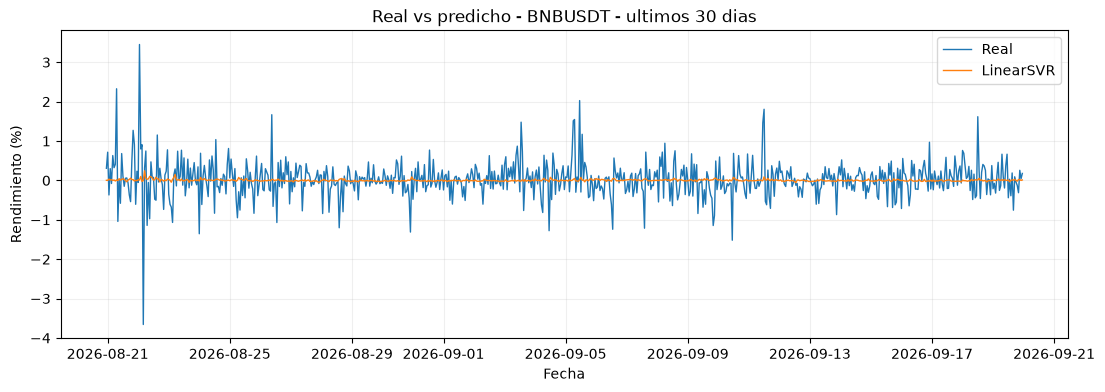

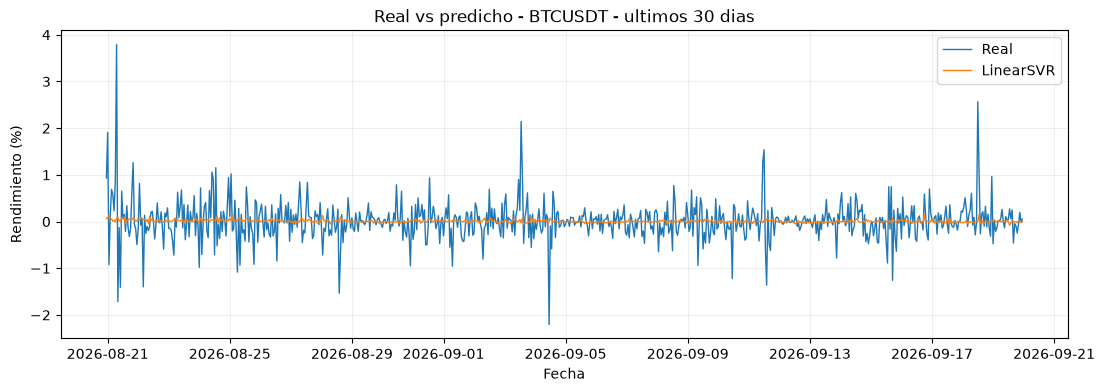

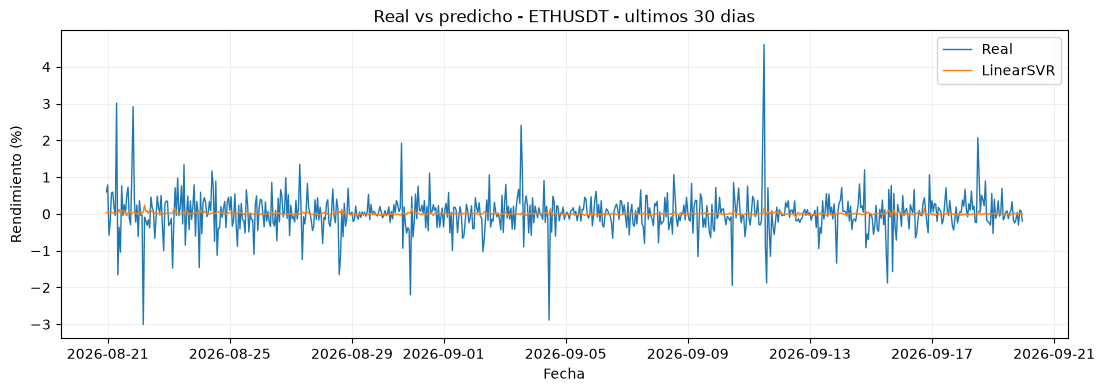

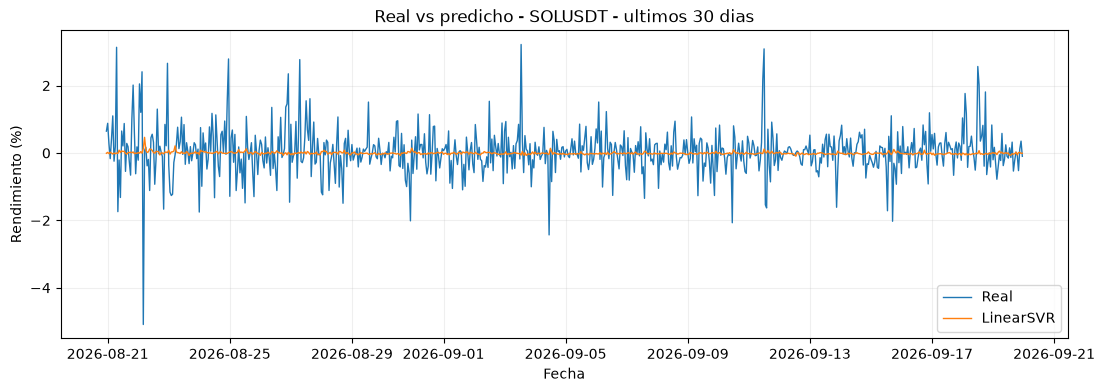

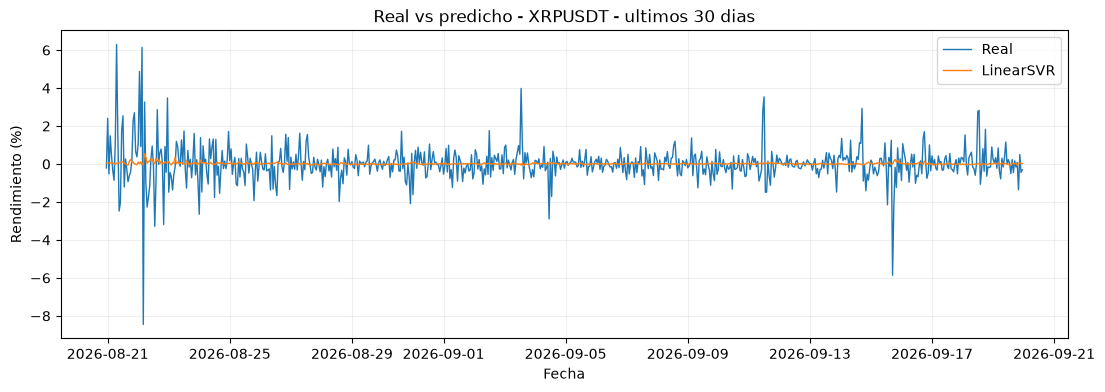

In [97]:
# ============================================================
# REAL VS PREDICHO
# ============================================================

for symbol, g in test_predictions_df.groupby(
    "symbol"
):

    g = (
        g.sort_values("open_time")
        .copy()
    )

    cutoff = (
        g["open_time"].max()
        -
        pd.Timedelta(days=30)
    )

    g_plot = g[
        g["open_time"] >= cutoff
    ]

    plt.figure(figsize=(13, 4))

    plt.plot(
        g_plot["open_time"],
        g_plot[target_col],
        label="Real",
        linewidth=1
    )

    plt.plot(
        g_plot["open_time"],
        g_plot["pred_linear_svr"],
        label="LinearSVR",
        linewidth=1
    )

    plt.title(
        f"Real vs predicho - {symbol} - ultimos 30 dias"
    )

    plt.xlabel("Fecha")
    plt.ylabel("Rendimiento (%)")

    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


## 3.8 Intervalos de confianza mediante bootstrap temporal

Se utilizan bloques móviles de 24 horas para construir intervalos de confianza
del 95 %.

El remuestreo por bloques preserva parcialmente la dependencia temporal y evita
tratar todas las observaciones horarias como independientes.

In [98]:
# ============================================================
# MOVING BLOCK BOOTSTRAP
# ============================================================

bootstrap_source = (
    test_predictions_df
    .sort_values(
        ["open_time", "symbol"]
    )
    .reset_index(drop=True)
)

unique_boot_times = (
    bootstrap_source[
        "open_time"
    ]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

time_rows = {
    t: np.flatnonzero(
        (
            bootstrap_source[
                "open_time"
            ] == t
        ).to_numpy()
    )
    for t in unique_boot_times
}

def block_bootstrap_metrics(
    pred_col,
    n_boot=200,
    block_size=24,
    seed=42
):

    rng = np.random.default_rng(seed)

    n_times = len(unique_boot_times)

    results = []

    for _ in range(n_boot):

        positions = []

        while len(positions) < n_times:

            max_start = max(
                n_times - block_size,
                0
            )

            start = (
                int(
                    rng.integers(
                        0,
                        max_start + 1
                    )
                )
                if max_start > 0
                else 0
            )

            positions.extend(
                range(
                    start,
                    min(
                        start + block_size,
                        n_times
                    )
                )
            )

        positions = positions[:n_times]

        rows = np.concatenate(
            [
                time_rows[
                    unique_boot_times[pos]
                ]
                for pos in positions
            ]
        )

        metrics = regression_metrics(
            bootstrap_source
            .iloc[rows][target_col],
            bootstrap_source
            .iloc[rows][pred_col]
        )

        results.append(metrics)

    return pd.DataFrame(results)


bootstrap_baseline = (
    block_bootstrap_metrics(
        "pred_persistencia",
        seed=42
    )
)

bootstrap_svr = (
    block_bootstrap_metrics(
        "pred_linear_svr",
        seed=43
    )
)

ci_rows = []

for name, boot in [
    (
        "Persistencia",
        bootstrap_baseline
    ),
    (
        "LinearSVR",
        bootstrap_svr
    )
]:

    for metric in [
        "RMSE",
        "MAE",
        "MAPE_pct",
        "R2"
    ]:

        ci_rows.append(
            {
                "Modelo": name,
                "Metrica": metric,
                "Media_bootstrap":
                    boot[metric].mean(),
                "IC_2.5%":
                    boot[metric].quantile(0.025),
                "IC_97.5%":
                    boot[metric].quantile(0.975)
            }
        )

bootstrap_ci_df = pd.DataFrame(
    ci_rows
)

display(
    bootstrap_ci_df.round(6)
)


,Modelo,Metrica,Media_bootstrap,IC_2.5%,IC_97.5%
0,Persistencia,RMSE,0.873061,0.830976,0.916294
1,Persistencia,MAE,0.584537,0.562422,0.607084
2,Persistencia,MAPE_pct,"476,575,197,711,526.875000","376,446,937,829,187.875000","583,691,992,051,046.125000"
3,Persistencia,R2,-0.990320,-1.040911,-0.933279
4,LinearSVR,RMSE,0.621426,0.592744,0.646122
5,LinearSVR,MAE,0.401967,0.387567,0.415604
6,LinearSVR,MAPE_pct,"31,944,673,835,128.003906","26,316,711,069,792.562500","38,840,100,602,156.460938"
7,LinearSVR,R2,-0.003116,-0.006464,0.000151


## 3.9 Diagnóstico de residuos

Los residuos se definen como:

$$
e_t=y_t-\widehat y_t.
$$

Se estudian su distribución, normalidad, heterocedasticidad y autocorrelación
temporal.

La presencia de estructura sistemática en los residuos indicaría información
que el modelo lineal no está capturando.

,media_residuo,std_residuo,JB_stat,JB_p,BP_stat,BP_p
symbol,,,,,,
BNBUSDT,-0.003165,0.531160,"75,478.525881",0.000000,385.305004,0.000000
BTCUSDT,-0.006125,0.446431,"43,927.422631",0.000000,290.782594,0.000000
ETHUSDT,-0.012684,0.652348,"46,425.440610",0.000000,266.393062,0.000000
SOLUSDT,0.002557,0.726264,"18,114.673132",0.000000,406.898585,0.000000
XRPUSDT,-0.018799,0.701917,"69,082.077300",0.000000,178.764592,0.000000


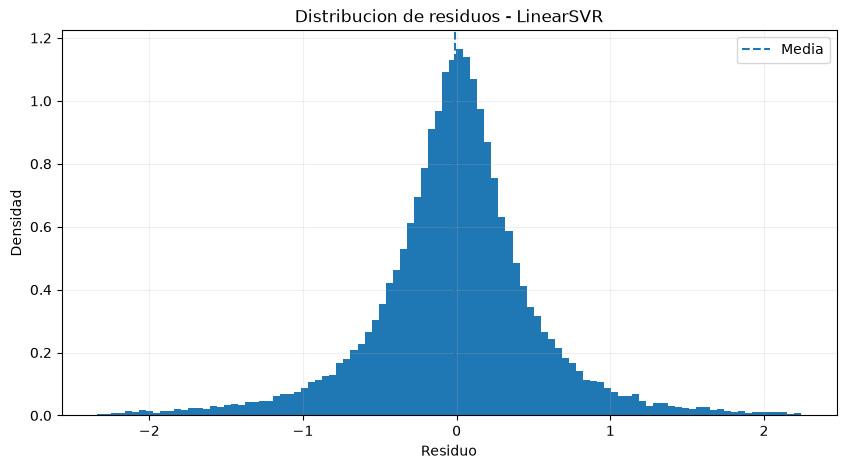

In [99]:
# ============================================================
# RESIDUOS, NORMALIDAD Y HETEROCEDASTICIDAD
# ============================================================

from scipy import stats
from statsmodels.stats.diagnostic import (
    het_breuschpagan
)
import statsmodels.api as sm

residual_df = test_predictions_df.copy()

residual_df[
    "residual"
] = (
    residual_df[target_col]
    -
    residual_df["pred_linear_svr"]
)

diagnostic_rows = []

for symbol, g in residual_df.groupby(
    "symbol"
):

    residuals = (
        g["residual"]
        .to_numpy()
    )

    predictions = (
        g["pred_linear_svr"]
        .to_numpy()
    )

    jb = stats.jarque_bera(
        residuals
    )

    bp_exog = sm.add_constant(
        predictions
    )

    bp = het_breuschpagan(
        residuals,
        bp_exog
    )

    diagnostic_rows.append(
        {
            "symbol": symbol,
            "media_residuo":
                residuals.mean(),
            "std_residuo":
                residuals.std(ddof=1),
            "JB_stat":
                jb.statistic,
            "JB_p":
                jb.pvalue,
            "BP_stat":
                bp[0],
            "BP_p":
                bp[1]
        }
    )

residual_diagnostics_df = (
    pd.DataFrame(
        diagnostic_rows
    )
    .set_index("symbol")
)

display(
    residual_diagnostics_df.round(6)
)

plt.figure(figsize=(10, 5))

low = residual_df[
    "residual"
].quantile(0.005)

high = residual_df[
    "residual"
].quantile(0.995)

plot_res = residual_df[
    residual_df["residual"]
    .between(low, high)
]

plt.hist(
    plot_res["residual"],
    bins=100,
    density=True
)

plt.axvline(
    residual_df[
        "residual"
    ].mean(),
    linestyle="--",
    label="Media"
)

plt.title(
    "Distribucion de residuos - LinearSVR"
)

plt.xlabel("Residuo")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 3.10 Autocorrelación de los residuos

Se calcula la ACF de los residuos hasta 48 horas.

Una autocorrelación residual importante indicaría dependencia temporal todavía
no capturada por el modelo.

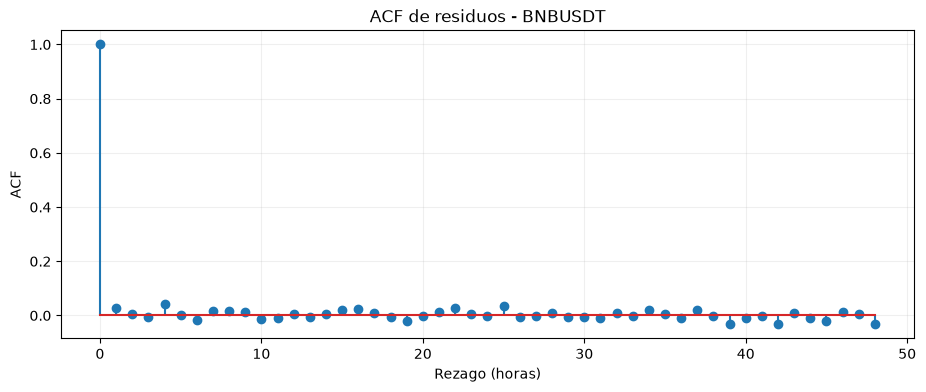

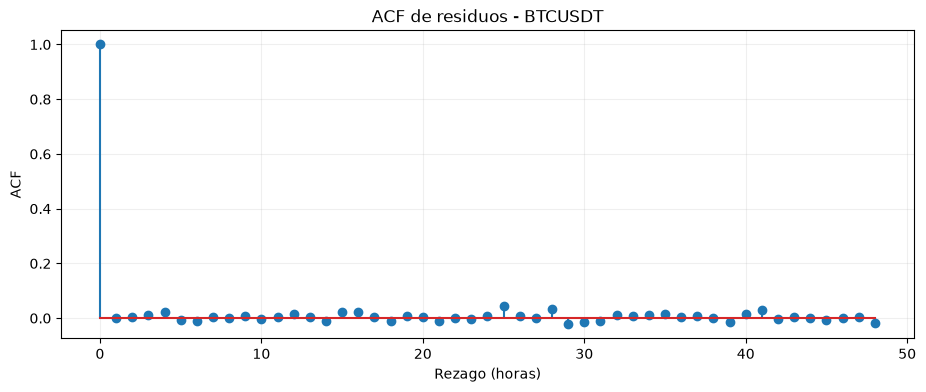

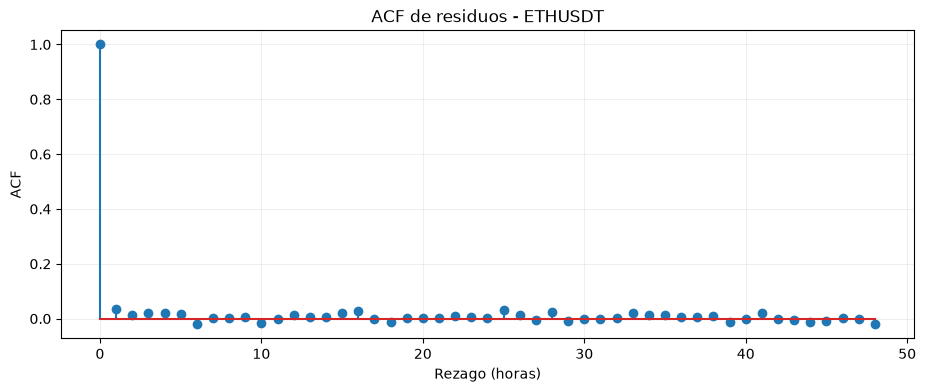

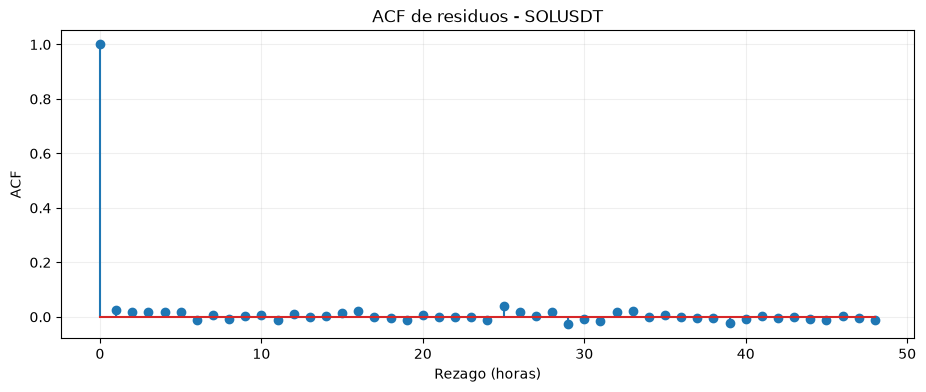

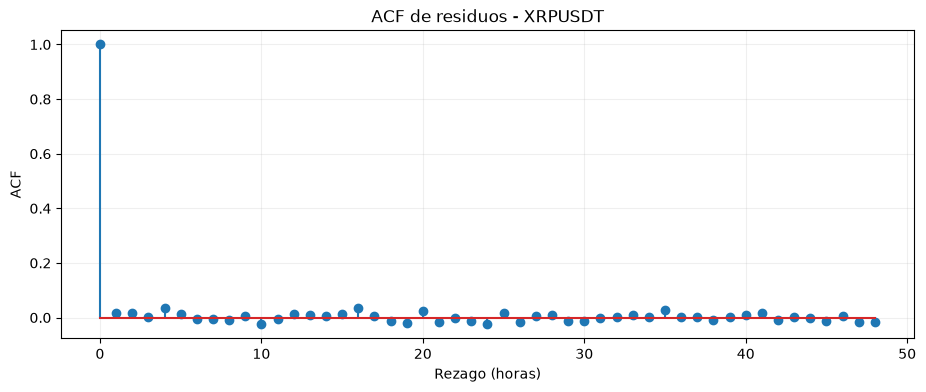

,symbol,lag,ACF_residual
0,BNBUSDT,1,0.027260
1,BNBUSDT,2,0.004984
2,BNBUSDT,3,-0.005906
5,BNBUSDT,6,-0.017335
11,BNBUSDT,12,0.003934
23,BNBUSDT,24,-0.003505
47,BNBUSDT,48,-0.031525
48,BTCUSDT,1,0.002248
49,BTCUSDT,2,0.005228
50,BTCUSDT,3,0.009860


In [100]:
# ============================================================
# ACF DE RESIDUOS
# ============================================================

from statsmodels.tsa.stattools import acf

residual_acf_rows = []

for symbol, g in residual_df.groupby(
    "symbol"
):

    residual_series = (
        g.sort_values("open_time")[
            "residual"
        ]
        .dropna()
        .to_numpy()
    )

    acf_values = acf(
        residual_series,
        nlags=48,
        fft=True
    )

    lags = np.arange(
        len(acf_values)
    )

    plt.figure(figsize=(11, 4))

    plt.stem(
        lags,
        acf_values
    )

    plt.title(
        f"ACF de residuos - {symbol}"
    )

    plt.xlabel("Rezago (horas)")
    plt.ylabel("ACF")
    plt.grid(alpha=0.2)
    plt.show()

    for lag in range(
        1,
        len(acf_values)
    ):

        residual_acf_rows.append(
            {
                "symbol": symbol,
                "lag": lag,
                "ACF_residual":
                    acf_values[lag]
            }
        )

residual_acf_df = pd.DataFrame(
    residual_acf_rows
)

display(
    residual_acf_df[
        residual_acf_df["lag"]
        .isin(
            [1, 2, 3, 6, 12, 24, 48]
        )
    ]
    .round(6)
)


## 3.11 Curva de aprendizaje temporal

Se utiliza el último fold como bloque fijo de validación.

El modelo se entrena progresivamente con 20 %, 40 %, 60 %, 80 % y 100 % del
bloque temporal de entrenamiento, respetando siempre el orden cronológico.

20% completado.


40% completado.


60% completado.


80% completado.


100% completado.


,fraccion_train,n_train,RMSE_train,RMSE_validacion
0,0.200000,34215,1.542259,0.858093
1,0.400000,68430,1.280732,0.841415
2,0.600000,102645,1.186550,0.840303
3,0.800000,136860,1.080408,0.839390
4,1.000000,171080,1.025774,0.838704


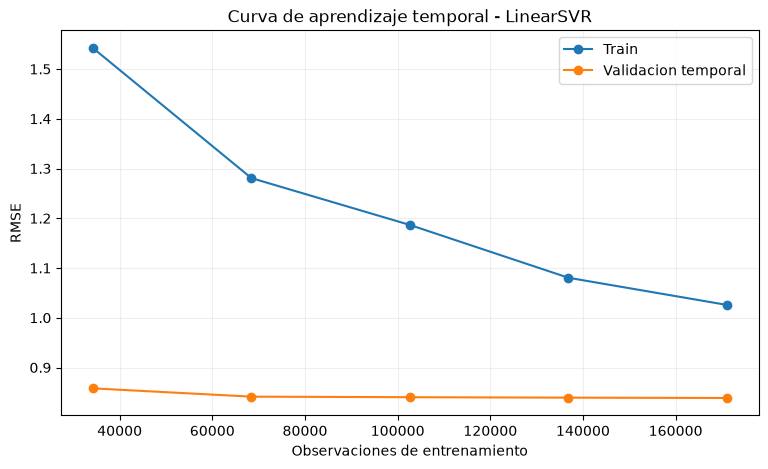

In [101]:
# ============================================================
# CURVA DE APRENDIZAJE TEMPORAL
# ============================================================

lc_train_idx, lc_val_idx = (
    panel_cv_splits[-1]
)

lc_train_rows = (
    train_model
    .iloc[lc_train_idx]
    .copy()
)

lc_times = (
    lc_train_rows[
        "open_time"
    ]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

learning_rows = []

for fraction in [
    0.20,
    0.40,
    0.60,
    0.80,
    1.00
]:

    n_times = max(
        int(
            len(lc_times)
            * fraction
        ),
        1
    )

    selected_times = set(
        lc_times.iloc[
            :n_times
        ]
    )

    subset_idx = np.flatnonzero(
        train_model[
            "open_time"
        ]
        .isin(
            selected_times
        )
        .to_numpy()
    )

    model_lc = clone(
        base_model_pipeline
    )

    model_lc.fit(
        X_train_model.iloc[
            subset_idx
        ],
        y_train_model.iloc[
            subset_idx
        ]
    )

    pred_train = model_lc.predict(
        X_train_model.iloc[
            subset_idx
        ]
    )

    pred_val = model_lc.predict(
        X_train_model.iloc[
            lc_val_idx
        ]
    )

    learning_rows.append(
        {
            "fraccion_train":
                fraction,
            "n_train":
                len(subset_idx),
            "RMSE_train":
                np.sqrt(
                    mean_squared_error(
                        y_train_model.iloc[
                            subset_idx
                        ],
                        pred_train
                    )
                ),
            "RMSE_validacion":
                np.sqrt(
                    mean_squared_error(
                        y_train_model.iloc[
                            lc_val_idx
                        ],
                        pred_val
                    )
                )
        }
    )

    print(
        f"{int(fraction*100)}% completado."
    )

learning_curve_df = pd.DataFrame(
    learning_rows
)

display(
    learning_curve_df.round(6)
)

plt.figure(figsize=(9, 5))

plt.plot(
    learning_curve_df["n_train"],
    learning_curve_df["RMSE_train"],
    marker="o",
    label="Train"
)

plt.plot(
    learning_curve_df["n_train"],
    learning_curve_df["RMSE_validacion"],
    marker="o",
    label="Validacion temporal"
)

plt.title(
    "Curva de aprendizaje temporal - LinearSVR"
)

plt.xlabel(
    "Observaciones de entrenamiento"
)

plt.ylabel("RMSE")

plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 3.12 Interpretación de coeficientes

Debido a que el modelo es lineal, pueden inspeccionarse sus coeficientes.

La magnitud de un coeficiente indica su peso dentro de la frontera lineal
aprendida, pero no debe interpretarse como una relación causal.

,variable,coeficiente,abs_coeficiente
1,numeric__high,2.339287,2.339287
3,numeric__close,-1.933334,1.933334
0,numeric__open,-1.927544,1.927544
2,numeric__low,1.515955,1.515955
9,numeric__log_return_1h,-0.534874,0.534874
28,numeric__candle_return_pct,0.516261,0.516261
4,numeric__volume,-0.090327,0.090327
5,numeric__quote_asset_volume,-0.074730,0.074730
8,numeric__taker_buy_quote_volume,0.050429,0.050429
27,numeric__intraday_range_pct,0.036763,0.036763


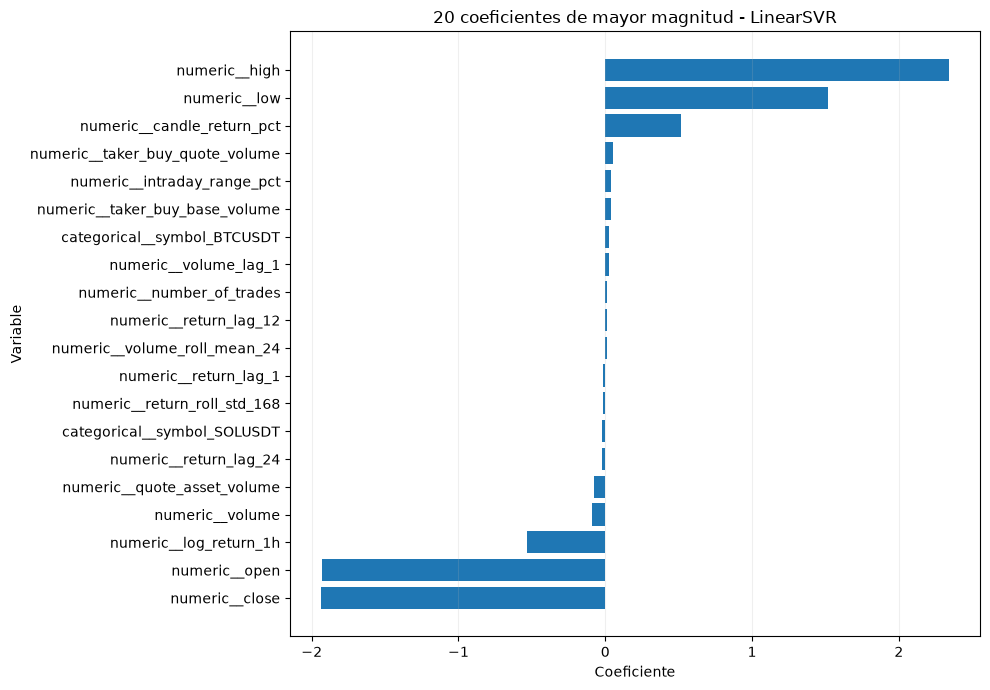

In [102]:
# ============================================================
# COEFICIENTES
# ============================================================

fitted_preprocessor = (
    final_model.named_steps[
        "preprocessor"
    ]
)

fitted_regressor = (
    final_model.named_steps[
        "regressor"
    ]
)

try:

    feature_names = (
        fitted_preprocessor
        .get_feature_names_out()
    )

except Exception:

    feature_names = np.array(
        [
            f"feature_{i}"
            for i
            in range(
                len(
                    fitted_regressor.coef_
                )
            )
        ]
    )

coefficients_df = pd.DataFrame(
    {
        "variable":
            feature_names,
        "coeficiente":
            fitted_regressor.coef_
    }
)

coefficients_df[
    "abs_coeficiente"
] = (
    coefficients_df[
        "coeficiente"
    ].abs()
)

top_coefficients_df = (
    coefficients_df
    .sort_values(
        "abs_coeficiente",
        ascending=False
    )
    .head(20)
)

display(
    top_coefficients_df.round(6)
)

plot_coef = (
    top_coefficients_df
    .sort_values(
        "coeficiente"
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_coef["variable"],
    plot_coef["coeficiente"]
)

plt.title(
    "20 coeficientes de mayor magnitud - LinearSVR"
)

plt.xlabel("Coeficiente")
plt.ylabel("Variable")

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()


## 3.13 Revisión crítica de desempeño elevado

La guía establece que un $R^2$ de aproximadamente 80 %--90 % o superior debe
activar una revisión especial de fuga de información, partición temporal,
autocorrelación y complejidad del problema.

La siguiente comprobación automatiza esta alerta.

In [103]:
# ============================================================
# CHECK DE R2 ALTO
# ============================================================

test_r2 = (
    svr_test_metrics["R2"]
)

print("=" * 75)
print("REVISION CRITICA")
print("=" * 75)

print(
    f"R2 test LinearSVR: {test_r2:.6f}"
)

print()

if test_r2 >= 0.80:

    print("ALERTA: R2 >= 0.80")
    print("- Revisar data leakage.")
    print("- Revisar fuga temporal.")
    print("- Revisar particion cronologica.")
    print("- Comparar con persistencia.")
    print("- Revisar ACF de residuos.")
    print("- Revisar complejidad del problema.")

else:

    print(
        "No se activa la alerta de R2 >= 0.80."
    )

print()

print(
    "RMSE Persistencia:",
    round(
        baseline_test_metrics["RMSE"],
        6
    )
)

print(
    "RMSE LinearSVR   :",
    round(
        svr_test_metrics["RMSE"],
        6
    )
)

print(
    "R2 Persistencia  :",
    round(
        baseline_test_metrics["R2"],
        6
    )
)

print(
    "R2 LinearSVR     :",
    round(
        svr_test_metrics["R2"],
        6
    )
)

print(
    "Mejora RMSE (%)  :",
    round(
        rmse_improvement,
        4
    )
)


REVISION CRITICA
R2 test LinearSVR: -0.003215

No se activa la alerta de R2 >= 0.80.

RMSE Persistencia: 0.874818
RMSE LinearSVR   : 0.620891
R2 Persistencia  : -0.991587
R2 LinearSVR     : -0.003215
Mejora RMSE (%)  : 29.0263


## 3.14 Interpretación de los resultados del modelo base

El modelo `LinearSVR` fue evaluado sobre un conjunto de prueba completamente
reservado y comparado con una línea base temporal de persistencia.

### Desempe?o frente a la línea base

En el conjunto de prueba se obtuvieron los siguientes resultados:

| Modelo | RMSE | $R^2$ |
|---|---:|---:|
| Persistencia | 0.874818 | -0.991587 |
| LinearSVR | 0.620891 | -0.003215 |

El `LinearSVR` reduce el RMSE desde **0.874818** hasta **0.620891**, lo que
representa una mejora aproximada del **29.03 %** respecto a la línea base de
persistencia.

Este resultado indica que el modelo supervisado produce predicciones
considerablemente menos erráticas que asumir que el rendimiento de la siguiente
hora será igual al rendimiento observado en la hora actual.

Sin embargo, el valor obtenido para el coeficiente de determinaci?n fue:

$$
R^2_{\text{LinearSVR}}=-0.003215.
$$

Este valor se encuentra prácticamente en cero, aunque ligeramente por debajo.
Por tanto, el modelo presenta una **capacidad explicativa muy limitada sobre la
variabilidad del rendimiento horario futuro**.

La línea base de persistencia obtuvo:

$$
R^2_{\text{Persistencia}}=-0.991587,
$$

lo cual muestra que utilizar directamente el rendimiento de la hora actual como
pron?stico de la siguiente hora constituye una referencia especialmente débil
para este problema.

En consecuencia, el `LinearSVR` mejora claramente a la persistencia en términos
de RMSE, pero esta mejora no implica una elevada capacidad para explicar la
variabilidad del rendimiento futuro.

### Curva de aprendizaje

La curva de aprendizaje temporal mostró los siguientes valores de RMSE de
validación:

| Fracci?n de entrenamiento | Observaciones | RMSE validación |
|---:|---:|---:|
| 20 % | 34 215 | 0.858093 |
| 40 % | 68 430 | 0.841415 |
| 60 % | 102 645 | 0.840303 |
| 80 % | 136 860 | 0.839390 |
| 100 % | 171 080 | 0.838704 |

El aumento de la cantidad de datos mejora progresivamente el desempeño de
validación. No obstante, la reducción del error se vuelve pequeña a partir de
aproximadamente el **60 % del conjunto de entrenamiento**.

Esto sugiere que el tamaño de muestra disponible es suficiente para estabilizar
el desempeño del modelo base y que simplemente incorporar más observaciones no
parece suficiente para producir una mejora sustancial bajo una especificaci?n
lineal.

Además, el RMSE de entrenamiento es superior al de validación en todos los
tamaños considerados. Este comportamiento no corresponde al patrón clásico de
sobreajuste. Debido a la estructura cronológica del problema, puede estar
relacionado con diferencias de volatilidad y distribución entre los distintos
periodos históricos.

### Diagn?stico de residuos

Las medias de los residuos obtenidas para los cinco criptoactivos fueron
cercanas a cero:

| Activo | Media del residuo | Desviaci?n estándar |
|---|---:|---:|
| BNBUSDT | -0.003165 | 0.531160 |
| BTCUSDT | -0.006125 | 0.446431 |
| ETHUSDT | -0.012684 | 0.652348 |
| SOLUSDT | 0.002557 | 0.726264 |
| XRPUSDT | -0.018799 | 0.701917 |

Las medias reducidas indican que no existe un sesgo promedio de gran magnitud en
las predicciones.

No obstante, la prueba de Jarque--Bera presentó valores $p<0.001$ para todos los
criptoactivos. Por tanto, se rechaza la hipótesis de normalidad de los residuos.

Este resultado es consistente con las características identificadas durante el
EDA, donde los rendimientos presentaron colas pesadas y eventos extremos.

La prueba de Breusch--Pagan también presentó valores $p<0.001$ para los cinco
activos. En consecuencia, existe evidencia de **heterocedasticidad**, es decir,
la varianza del error no permanece constante.

Este comportamiento es coherente con la dinámica de los mercados de
criptomonedas, en los cuales pueden alternarse periodos de baja y alta
volatilidad.

### Autocorrelación de los residuos

La ACF de los residuos presentó valores de magnitud reducida.

En el primer rezago se obtuvieron aproximadamente:

| Activo | ACF rezago 1 |
|---|---:|
| BNBUSDT | 0.027260 |
| BTCUSDT | 0.002248 |
| ETHUSDT | 0.034047 |
| SOLUSDT | 0.025130 |
| XRPUSDT | 0.017020 |

Para los rezagos 2, 3, 6, 12, 24 y 48 horas las autocorrelaciones también se
mantuvieron próximas a cero, aproximadamente dentro del intervalo observado de
**-0.032 a 0.034**.

Por tanto, no se identifica una autocorrelación lineal residual de gran
magnitud.

Dado el elevado tamaño de muestra, algunos coeficientes pequeños podrían ser
estadísticamente significativos; sin embargo, desde el punto de vista práctico,
sus magnitudes son reducidas.

Esto sugiere que las limitaciones del `LinearSVR` no se deben principalmente a
una fuerte dependencia lineal temporal omitida.

### Interpretación general

Los resultados muestran que el `LinearSVR` constituye una referencia supervisada
más adecuada que la persistencia, ya que reduce el RMSE aproximadamente un
**29.03 %**.

Sin embargo, el valor

$$
R^2=-0.003215
$$

indica que el modelo lineal prácticamente no explica la variabilidad del
rendimiento de la hora siguiente.

Al mismo tiempo, los residuos presentan:

- media cercana a cero;
- ausencia de autocorrelaciones lineales residuales de gran magnitud;
- fuerte evidencia de no normalidad;
- evidencia de heterocedasticidad.

En conjunto, estos resultados sugieren que la principal dificultad del problema
no corresponde simplemente a una dependencia temporal lineal que haya quedado
sin modelar. La estructura restante parece estar asociada principalmente con la
elevada variabilidad, las colas pesadas, los cambios de volatilidad y posibles
relaciones no lineales presentes en los rendimientos horarios.

Por esta razón, el `LinearSVR` cumple adecuadamente su funci?n como **modelo
base**. Cualquier modelo más complejo desarrollado posteriormente deberá
demostrar una mejora fuera de muestra respecto tanto a este modelo como a la
línea base de persistencia.

Finalmente, la alerta establecida en la guía para desempeños anormalmente altos
no se activa, debido a que el $R^2$ obtenido se encuentra muy por debajo del
intervalo del 80 %--90 %. No obstante, la auditoría de fuga de información
realizada en la Secci?n 2.5 permanece como parte integral de la validación
metodológica del proyecto.


## 3.15 Reproducibilidad

Se utiliza la semilla aleatoria `SEED = 42`.

La partición cronológica, ingeniería de características, pipeline de
preprocesamiento, folds temporales, modelo base y procedimientos de evaluación
quedan definidos explícitamente dentro de este mismo notebook.

De esta forma, `model_evaluation.ipynb` contiene en un único archivo el EDA,
preprocesamiento y modelo base requeridos para el entregable.